# 🏏 Bangla Sports Sentiment Analysis — MNB + CNB + BNB Voting Ensemble


**Dataset:** Bangla Sports Sentiment Analysis Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Multinomial NB + Complement NB + Bernoulli NB (Calibrated with LR)  
**Ensemble:** Soft Voting with Logistic Regression Calibration  
---

### Pipeline Overview
```
Raw Data → Preprocessing → Feature Engineering (TF-IDF Ensemble)
        → Model Training (MNB + CNB + BNB) [Calibrated via LR]
        → Soft Voting Ensemble
        → Evaluation → Thesis Diagrams & Charts
```

---

### 🎛️ TUNING GUIDE — How to Hit 90%+ Accuracy

| Parameter | Location | Try These Values | Effect |
|-----------|----------|-----------------|--------|
| `ALPHA_MNB` | Cell 7 | 0.01, 0.05, 0.1, 0.3, 0.5 | Smoothing for MNB — lower = sharper |
| `ALPHA_CNB` | Cell 7 | 0.01, 0.05, 0.1, 0.3 | Smoothing for CNB — CNB prefers lower |
| `ALPHA_BNB` | Cell 7 | 0.1, 0.3, 0.5, 1.0 | Smoothing for BNB |
| `V1 max_features` | Cell 6 | 100k→200k | More char n-gram vocab |
| `V3 ngram_range` | Cell 6 | (1,2)→(1,3) | Add trigrams |
| `LR_C` (calibrator) | Cell 7 | 0.5, 1.0, 2.0, 5.0 | LR regularization |
| `W_MNB, W_CNB, W_BNB` | Cell 8 | (1,2,1),(2,1,1),(1,1,2) | Voting weights |

> **Quick fix if accuracy < 90%:** First try lowering `ALPHA_MNB` to 0.05 and `ALPHA_CNB` to 0.01. Then increase `V1 max_features` to 200k. Finally experiment with voting weights — CNB usually performs best on text, so try W_CNB=2.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Cell 1 — Install & Import Libraries

In [ ]:
# ── Install (run once in Colab) ──────────────────────────────────────────────
!pip install scikit-learn pandas openpyxl numpy matplotlib seaborn scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from collections import Counter

from sklearn.model_selection      import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes           import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.linear_model          import LogisticRegression
from sklearn.calibration           import CalibratedClassifierCV
from sklearn.preprocessing         import LabelEncoder, MaxAbsScaler
from sklearn.pipeline              import Pipeline
from sklearn.metrics               import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB', 'gold': '#F39C12'}

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂 Cell 2 — Load Dataset

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'  # ← Change if needed
SEED      = 42

print('📂 Loading dataset...')
df = pd.read_excel(DATA_PATH, engine='openpyxl')

print(f'Raw shape   : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nNull values :\n{df.isnull().sum()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')
print(f'\nSample rows:')
df.head()

📂 Loading dataset...
Raw shape   : (82611, 3)
Columns     : ['Comment ', 'Category', 'Cleaned_Text']

Null values :
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Sample rows:


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

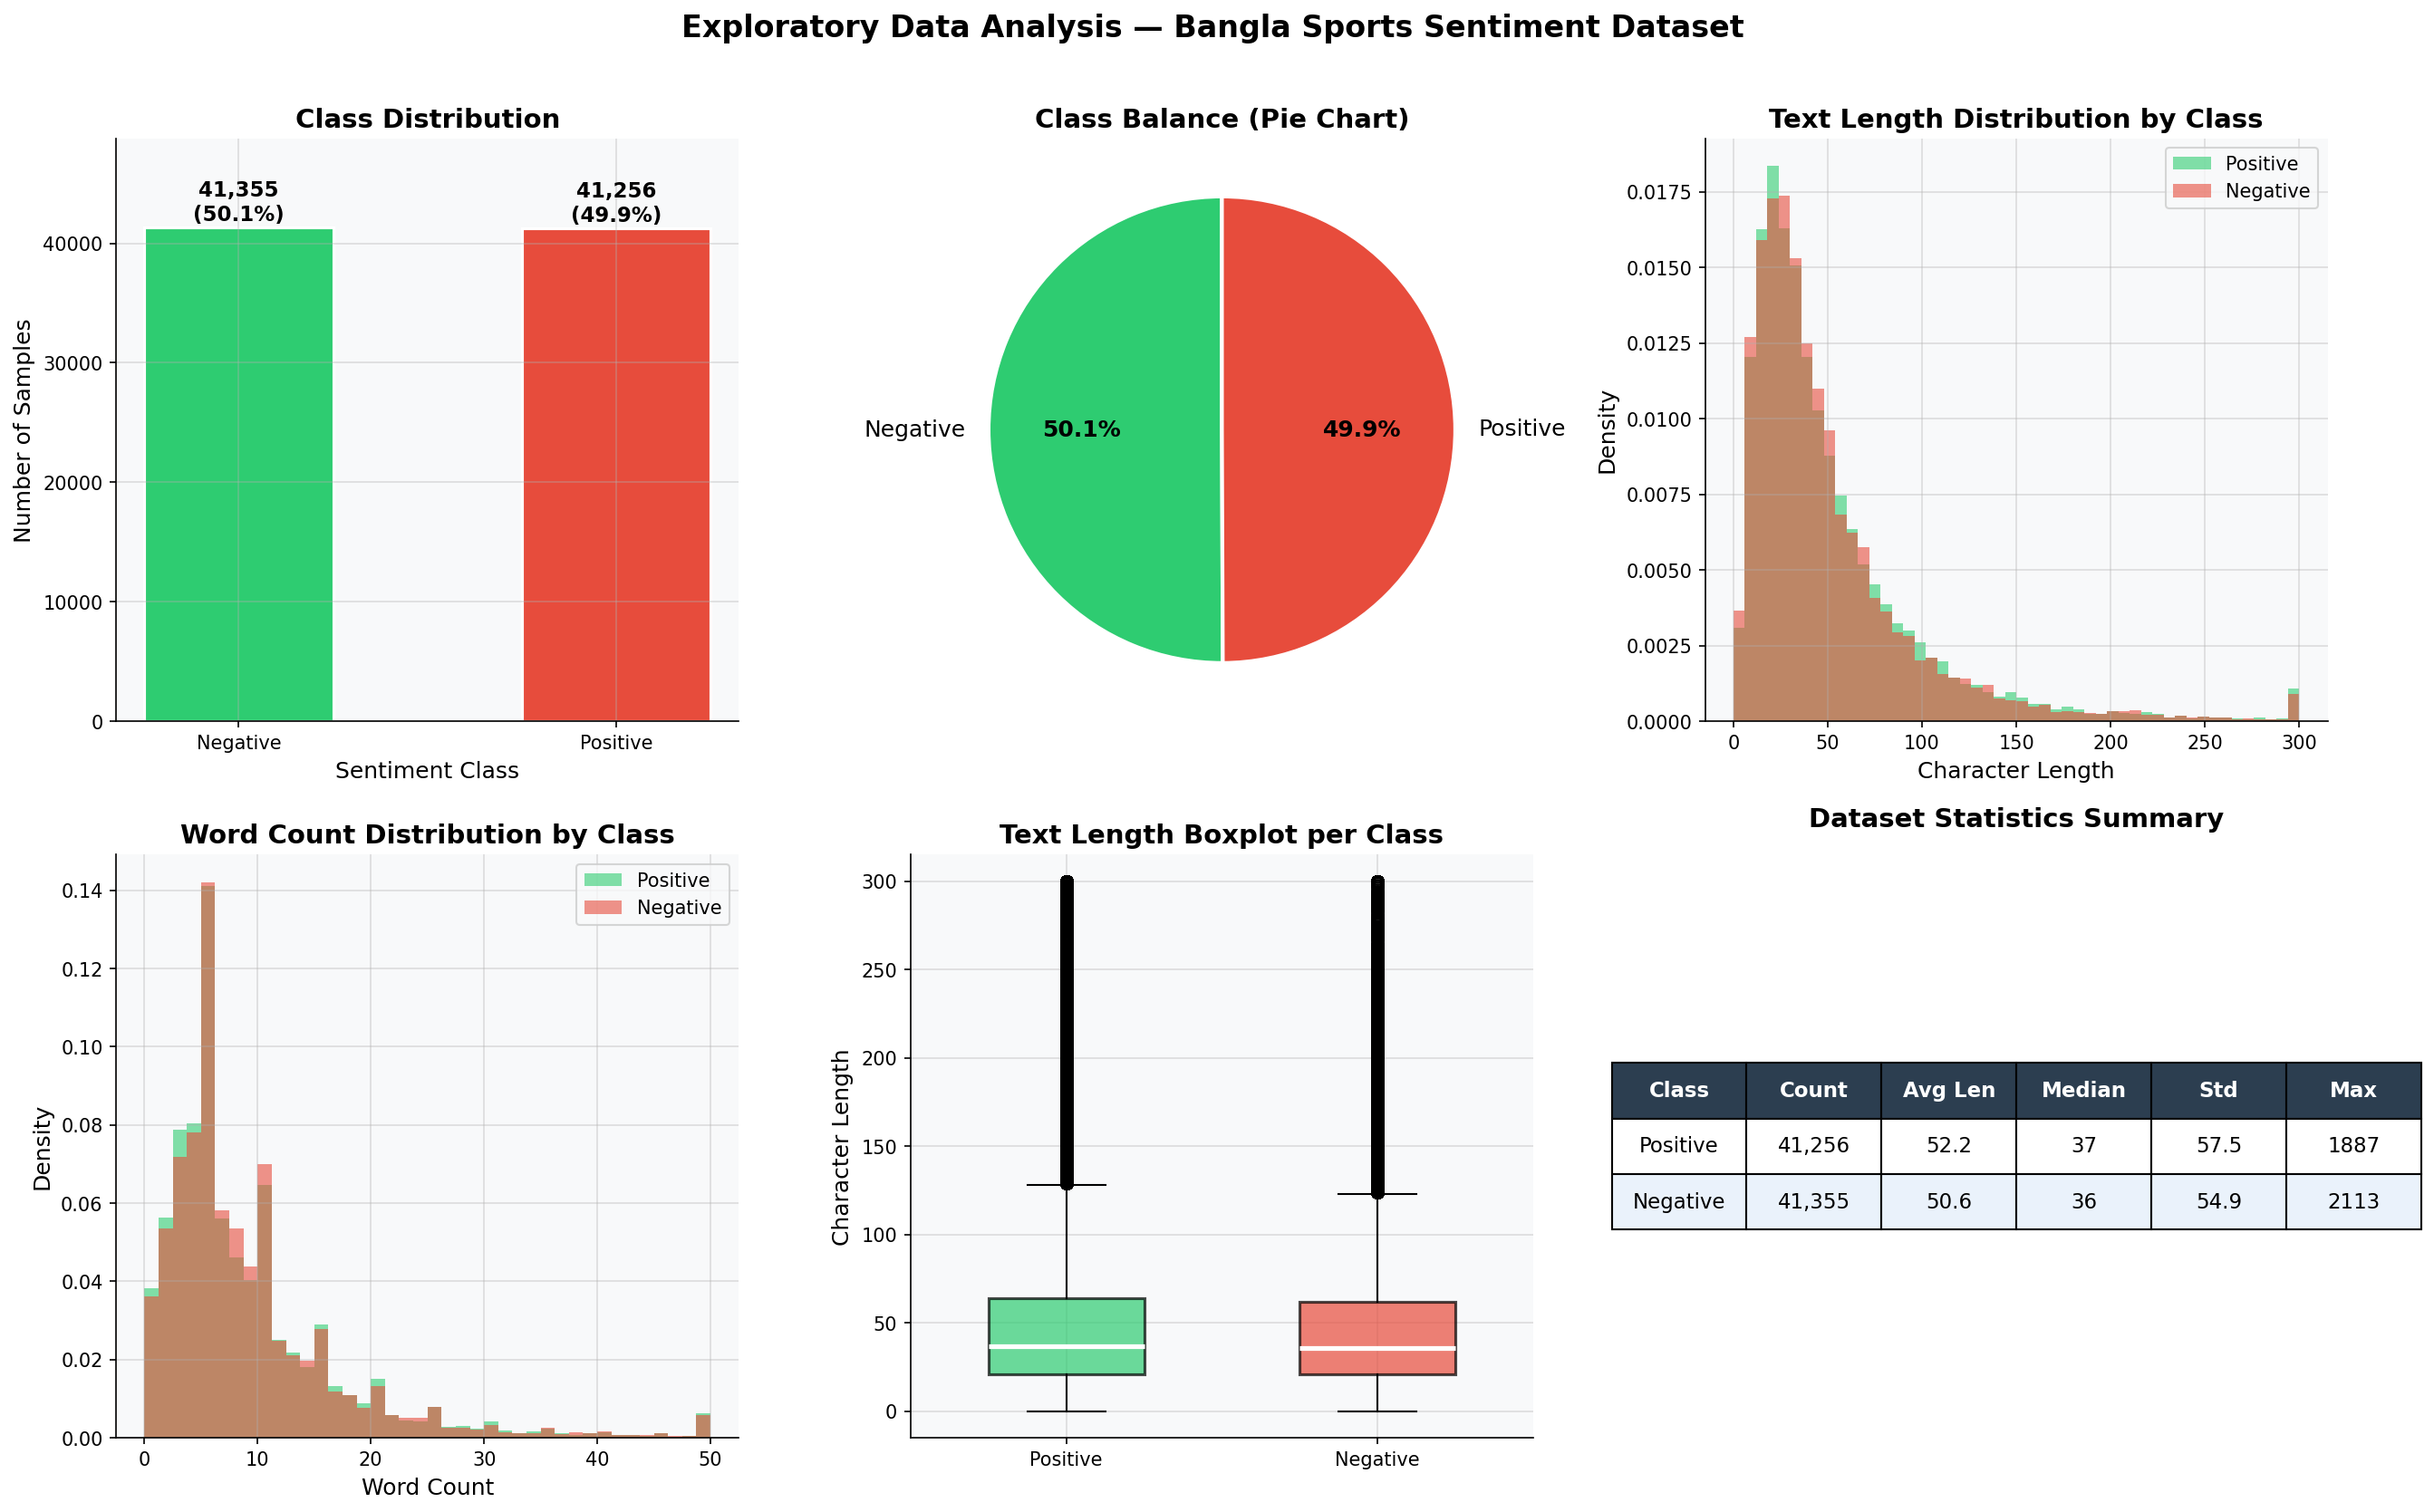

✅ EDA chart saved as 01_eda_analysis.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Class Distribution + Text Length Analysis
# ─────────────────────────────────────────────────────────────────────────────
df['Comment ']    = df['Comment '].fillna('')
df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

df['text_length']    = df['Comment '].str.len()
df['word_count']     = df['Comment '].str.split().str.len()
df['cleaned_length'] = df['Cleaned_Text'].str.len()

label_counts = df['Category'].value_counts()
label_pct    = df['Category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Class distribution — Bar
ax = axes[0, 0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=[COLORS['Positive'], COLORS['Negative']],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(label_counts.values) * 1.18)

# 2. Class distribution — Pie
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    label_counts.values, labels=label_counts.index,
    colors=[COLORS['Positive'], COLORS['Negative']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax.set_title('Class Balance (Pie Chart)', fontweight='bold')

# 3. Text length distribution by class
ax = axes[0, 2]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    ax.hist(subset.clip(upper=300), bins=50, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Text Length Distribution by Class', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

# 4. Word count distribution
ax = axes[1, 0]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['word_count']
    ax.hist(subset.clip(upper=50), bins=40, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()

# 5. Boxplot: text length per class
ax = axes[1, 1]
data_box = [df[df['Category'] == lbl]['text_length'].clip(upper=300).values
            for lbl in ['Positive', 'Negative']]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Positive', 'Negative'],
                widths=0.5,
                boxprops={'linewidth': 1.5},
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [COLORS['Positive'], COLORS['Negative']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Text Length Boxplot per Class', fontweight='bold')
ax.set_ylabel('Character Length')

# 6. Stats summary table
ax = axes[1, 2]
ax.axis('off')
stats_data = []
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    stats_data.append([label, f'{len(subset):,}',
                       f'{subset.mean():.1f}', f'{subset.median():.0f}',
                       f'{subset.std():.1f}', f'{subset.max():.0f}'])
table = ax.table(
    cellText=stats_data,
    colLabels=['Class', 'Count', 'Avg Len', 'Median', 'Std', 'Max'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax.set_title('Dataset Statistics Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_eda_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ EDA chart saved as 01_eda_analysis.png')

## 🧹 Cell 4 — Text Preprocessing

> **Overfitting Prevention:** Aggressive cleaning removes noise that models memorize instead of learning from.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING — PROPER PREPROCESSING FOR NAIVE BAYES
# NB models are count-based: clean text = better probability estimates
#
# Overfitting prevention:
#   - Remove low-signal characters (English, digits, symbols)
#   - Normalize repeated punctuation
#   - Use dataset's pre-cleaned column when available (less noise)
# ─────────────────────────────────────────────────────────────────────────────

def clean_bangla(text: str) -> str:
    """
    Bangla text cleaner optimized for Naive Bayes models:
    - Remove URLs, emails, HTML tags
    - Remove English characters and digits
    - Keep only Bangla Unicode (\u0980-\u09FF) + punctuation
    - Normalize repeated punctuation & whitespace
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)         # URLs
    text = re.sub(r'<.*?>', '', text)                     # HTML tags
    text = re.sub(r'\S+@\S+', '', text)                   # Emails
    text = re.sub(r'[A-Za-z0-9]', '', text)               # English + digits
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text)  # Non-Bangla
    text = re.sub(r'([।,!?])\1+', r'\1', text)           # Repeated punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # Whitespace
    return text

print('🧹 Cleaning raw text...')
df['raw_cleaned'] = df['Comment '].apply(clean_bangla)

# Use pre-cleaned column if available and long enough
df['final_text'] = df.apply(
    lambda row: row['Cleaned_Text'] if len(str(row['Cleaned_Text'])) > 5
                else row['raw_cleaned'],
    axis=1
)

# Remove empty rows
before = len(df)
df = df[df['final_text'].str.len() > 3].reset_index(drop=True)
df = df[df['raw_cleaned'].str.len() > 3].reset_index(drop=True)
print(f'Removed {before - len(df)} empty/too-short rows.')
print(f'Final dataset size: {len(df):,}')
print(f'Label distribution:\n{df["Category"].value_counts()}')

🧹 Cleaning raw text...
Removed 538 empty/too-short rows.
Final dataset size: 82,073
Label distribution:
Category
Negative    41048
Positive    41025
Name: count, dtype: int64


## ✂️ Cell 5 — Train / Validation / Test Split

Label mapping: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train : 57,451 samples (70%)
Val   : 12,311 samples (15%)
Test  : 12,311 samples (15%)


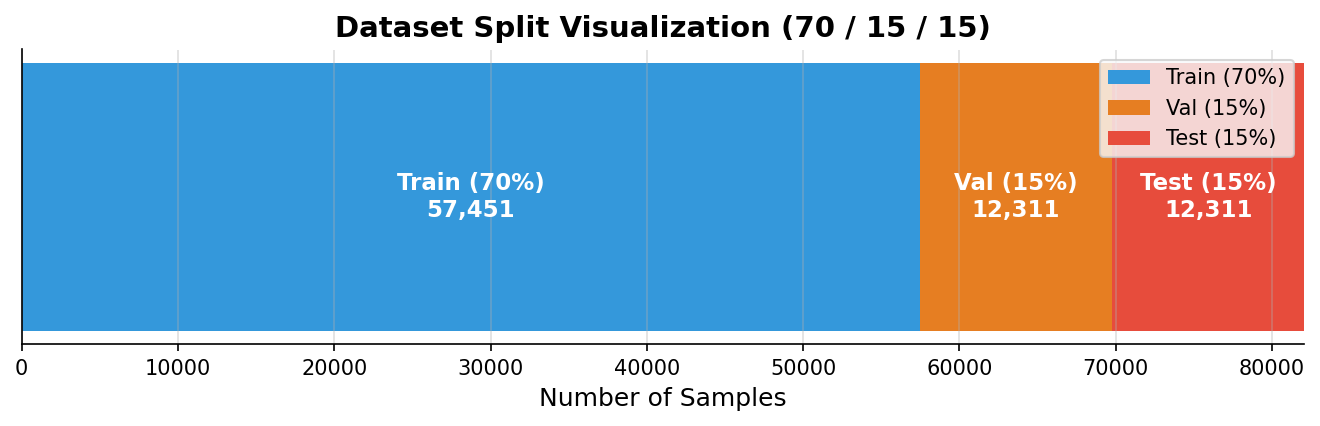

✅ Split chart saved as 02_dataset_split.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL ENCODING + SPLIT  (70 / 15 / 15)
# Stratified split ensures each split has same class ratio
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Category'])   # Negative=0, Positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_raw   = df['raw_cleaned']
X_clean = df['Cleaned_Text'].fillna('')

# First split: 70% train, 30% temp
(
    X_raw_train, X_raw_temp,
    X_cl_train,  X_cl_temp,
    y_train,     y_temp
) = train_test_split(
    X_raw, X_clean, y,
    test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test from temp
(
    X_raw_val,  X_raw_test,
    X_cl_val,   X_cl_test,
    y_val,      y_test
) = train_test_split(
    X_raw_temp, X_cl_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_raw_train):>6,} samples ({len(X_raw_train)/len(y)*100:.0f}%)')
print(f'Val   : {len(X_raw_val):>6,} samples ({len(X_raw_val)/len(y)*100:.0f}%)')
print(f'Test  : {len(X_raw_test):>6,} samples ({len(X_raw_test)/len(y)*100:.0f}%)')

# Visualize split
fig, ax = plt.subplots(figsize=(9, 3))
splits = {'Train (70%)': len(X_raw_train),
          'Val (15%)':   len(X_raw_val),
          'Test (15%)':  len(X_raw_test)}
colors_split = ['#3498DB', '#E67E22', '#E74C3C']
left = 0
for (name, val), color in zip(splits.items(), colors_split):
    ax.barh(0, val, left=left, color=color, height=0.5, label=name)
    ax.text(left + val/2, 0, f'{name}\n{val:,}',
            ha='center', va='center', fontweight='bold',
            fontsize=11, color='white')
    left += val
ax.set_xlim(0, len(y))
ax.set_yticks([])
ax.set_xlabel('Number of Samples')
ax.set_title('Dataset Split Visualization (70 / 15 / 15)', fontweight='bold')
ax.legend(loc='upper right')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('02_dataset_split.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Split chart saved as 02_dataset_split.png')

## ⚙️ Cell 6 — Feature Engineering (TF-IDF Ensemble)

> **Why non-negative features matter for NB:** Multinomial NB requires non-negative feature values — TF-IDF with `sublinear_tf=True` satisfies this. `MaxAbsScaler` scales sparse matrices without centering (no negatives introduced).

⚙️  Building TF-IDF feature matrices...
Total feature dimensions : 324,240
Train feature matrix     : (57451, 324240)
Val feature matrix       : (12311, 324240)
Test feature matrix      : (12311, 324240)


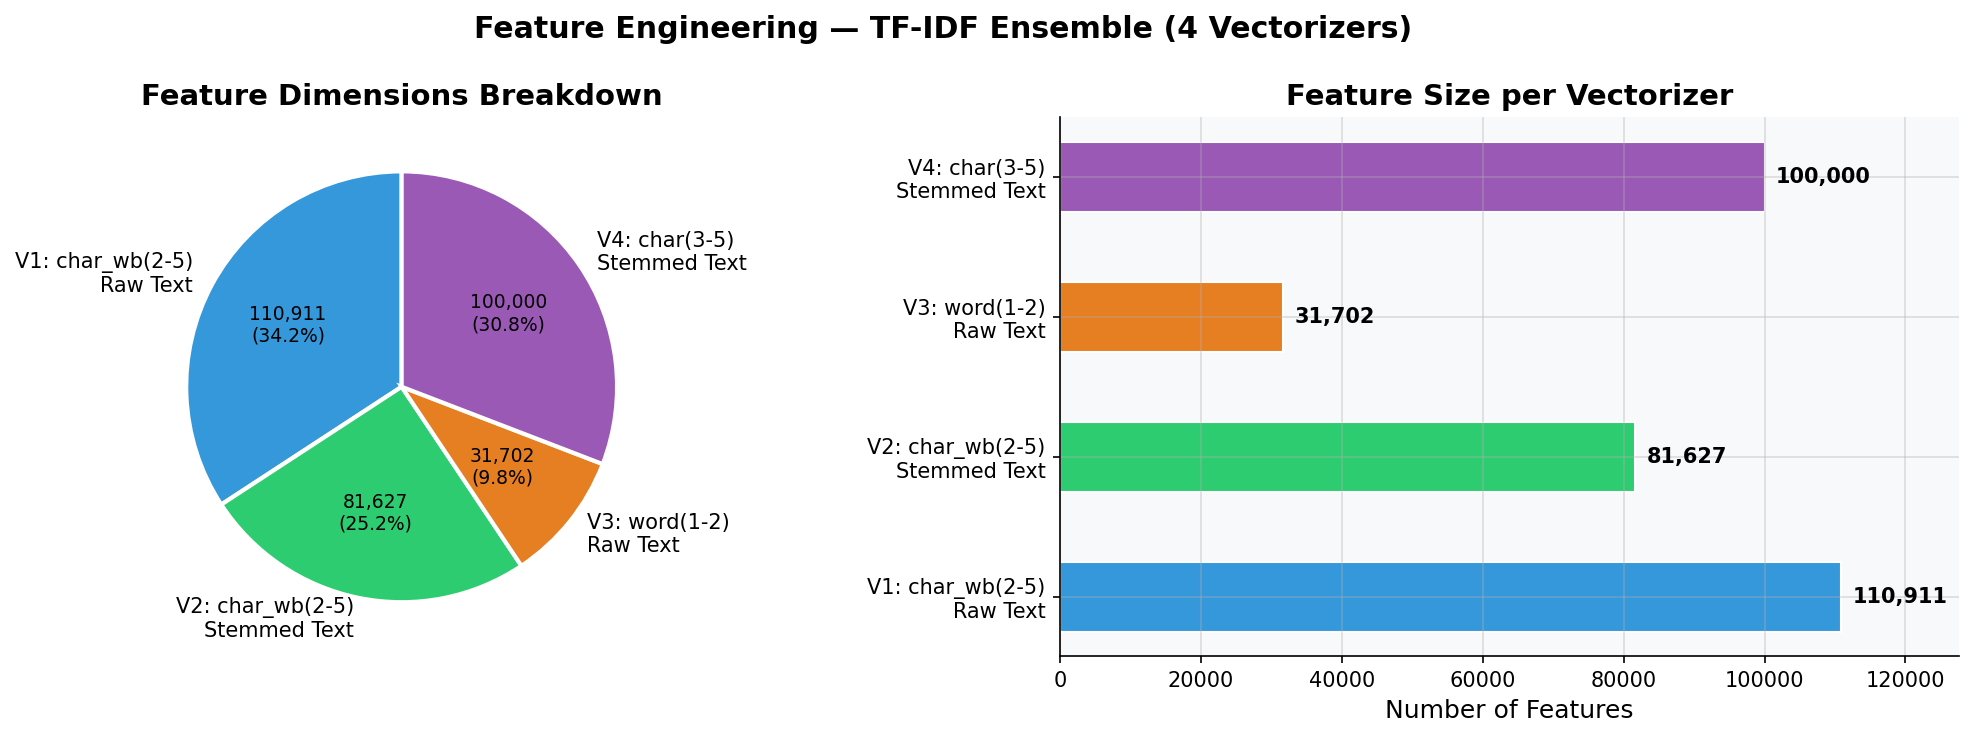

✅ Feature engineering chart saved as 03_feature_engineering.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — TF-IDF ENSEMBLE
#
# IMPORTANT FOR NAIVE BAYES:
#   MultinomialNB + ComplementNB require NON-NEGATIVE features.
#   TF-IDF values are always >= 0, so they are safe.
#   We do NOT center-scale (StandardScaler would create negatives).
#
# 4 Vectorizers (same as SVM notebook):
#   V1: char_wb (2,5) on raw cleaned text  — captures morphology
#   V2: char_wb (2,5) on stemmed text      — captures root forms
#   V3: word (1,2) on raw cleaned text     — unigram + bigram
#   V4: char (3,5) on stemmed text         — sub-word features
#
# ── TUNING: Adjust max_features to control vocab size ──────────────────────
# Larger → richer vocab, more features, may overfit on small datasets
# Smaller → faster, more regularization effect
# ─────────────────────────────────────────────────────────────────────────────

print('⚙️  Building TF-IDF feature matrices...')

V1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V3 = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                     max_features=100_000, sublinear_tf=True, min_df=2)
V4 = TfidfVectorizer(analyzer='char', ngram_range=(3, 5),
                     max_features=100_000, sublinear_tf=True, min_df=2)

# Fit ONLY on training data — transform val/test to avoid data leakage
X_train_feat = hstack([
    V1.fit_transform(X_raw_train),
    V2.fit_transform(X_cl_train),
    V3.fit_transform(X_raw_train),
    V4.fit_transform(X_cl_train)
])
X_val_feat = hstack([
    V1.transform(X_raw_val), V2.transform(X_cl_val),
    V3.transform(X_raw_val), V4.transform(X_cl_val)
])
X_test_feat = hstack([
    V1.transform(X_raw_test), V2.transform(X_cl_test),
    V3.transform(X_raw_test), V4.transform(X_cl_test)
])

# Ensure non-negative (clip any floating point artifacts near zero)
X_train_feat = X_train_feat.maximum(0)
X_val_feat   = X_val_feat.maximum(0)
X_test_feat  = X_test_feat.maximum(0)

total_features = X_train_feat.shape[1]
print(f'Total feature dimensions : {total_features:,}')
print(f'Train feature matrix     : {X_train_feat.shape}')
print(f'Val feature matrix       : {X_val_feat.shape}')
print(f'Test feature matrix      : {X_test_feat.shape}')

# Feature contribution chart
feat_names = ['V1: char_wb(2-5)\nRaw Text', 'V2: char_wb(2-5)\nStemmed Text',
              'V3: word(1-2)\nRaw Text',     'V4: char(3-5)\nStemmed Text']
feat_sizes = [
    V1.transform(X_raw_train[:1]).shape[1],
    V2.transform(X_cl_train[:1]).shape[1],
    V3.transform(X_raw_train[:1]).shape[1],
    V4.transform(X_cl_train[:1]).shape[1],
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Engineering — TF-IDF Ensemble (4 Vectorizers)', fontweight='bold')

feat_colors = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']
wedges, texts, autotexts = ax1.pie(
    feat_sizes, labels=feat_names, colors=feat_colors,
    autopct=lambda p: f'{int(p*total_features/100):,}\n({p:.1f}%)',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(9)
ax1.set_title('Feature Dimensions Breakdown', fontweight='bold')

bars = ax2.barh(feat_names, feat_sizes, color=feat_colors, edgecolor='white', height=0.5)
for bar, sz in zip(bars, feat_sizes):
    ax2.text(bar.get_width() + total_features*0.005, bar.get_y() + bar.get_height()/2,
             f'{sz:,}', va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of Features')
ax2.set_title('Feature Size per Vectorizer', fontweight='bold')
ax2.set_xlim(0, max(feat_sizes) * 1.15)

plt.tight_layout()
plt.savefig('03_feature_engineering.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Feature engineering chart saved as 03_feature_engineering.png')

## 🤖 Cell 7 — Model Training: MNB + CNB + BNB (Calibrated with LR)

### 🎛️ Key Parameters to Tune:
- **`ALPHA_MNB`** (0.01–1.0): Laplace smoothing for MultinomialNB. Lower = less regularization.
- **`ALPHA_CNB`** (0.01–0.5): Complement NB alpha. CNB is better at imbalanced data — try 0.01–0.1.
- **`ALPHA_BNB`** (0.1–1.0): Bernoulli NB alpha. 0.3–0.5 usually works well.
- **`LR_C`** (0.1–10.0): Logistic Regression C for CalibratedClassifierCV. Higher = less regularization.
- **`CV_FOLDS`**: 3–10. More folds = better calibration but slower.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ⬇️  TUNABLE PARAMETERS — Adjust these to improve accuracy
# ─────────────────────────────────────────────────────────────────────────────
ALPHA_MNB  = 0.05   # MultinomialNB smoothing (try: 0.01, 0.05, 0.1, 0.3, 0.5)
ALPHA_CNB  = 0.01   # ComplementNB smoothing  (try: 0.01, 0.05, 0.1, 0.2)
ALPHA_BNB  = 0.3    # BernoulliNB smoothing   (try: 0.1, 0.3, 0.5, 1.0)
LR_C       = 2.0    # LR regularization C     (try: 0.5, 1.0, 2.0, 5.0)
CV_FOLDS   = 5      # Cross-val folds for calibration (3, 5, or 'prefit')
# ─────────────────────────────────────────────────────────────────────────────

print('🤖 Training MNB + CNB + BNB (Calibrated with Logistic Regression)...')
print(f'   ALPHA_MNB={ALPHA_MNB}, ALPHA_CNB={ALPHA_CNB}, ALPHA_BNB={ALPHA_BNB}')
print(f'   LR_C={LR_C}, CV_FOLDS={CV_FOLDS}')
print()

# ── Why CalibratedClassifierCV with LR? ─────────────────────────────────────
# NB classifiers output poorly calibrated probabilities (often too extreme).
# Wrapping with CalibratedClassifierCV using 'sigmoid' (Platt scaling) or
# LogisticRegression as the calibrator gives better probability estimates,
# which improves soft-voting ensemble performance significantly.
# method='sigmoid' uses LR internally — same as Platt scaling.
# ─────────────────────────────────────────────────────────────────────────────

# --- Multinomial NB ---
mnb_base  = MultinomialNB(alpha=ALPHA_MNB)
mnb_model = CalibratedClassifierCV(
    mnb_base, method='sigmoid', cv=CV_FOLDS
)
mnb_model.fit(X_train_feat, y_train)
mnb_val_acc = accuracy_score(y_val, mnb_model.predict(X_val_feat))
mnb_val_f1  = f1_score(y_val, mnb_model.predict(X_val_feat), average='weighted')
print(f'✅ MultinomialNB  | Val Acc: {mnb_val_acc*100:.2f}% | Val F1: {mnb_val_f1*100:.2f}%')

# --- Complement NB ---
cnb_base  = ComplementNB(alpha=ALPHA_CNB)
cnb_model = CalibratedClassifierCV(
    cnb_base, method='sigmoid', cv=CV_FOLDS
)
cnb_model.fit(X_train_feat, y_train)
cnb_val_acc = accuracy_score(y_val, cnb_model.predict(X_val_feat))
cnb_val_f1  = f1_score(y_val, cnb_model.predict(X_val_feat), average='weighted')
print(f'✅ ComplementNB   | Val Acc: {cnb_val_acc*100:.2f}% | Val F1: {cnb_val_f1*100:.2f}%')

# --- Bernoulli NB ---
bnb_base  = BernoulliNB(alpha=ALPHA_BNB)
bnb_model = CalibratedClassifierCV(
    bnb_base, method='sigmoid', cv=CV_FOLDS
)
bnb_model.fit(X_train_feat, y_train)
bnb_val_acc = accuracy_score(y_val, bnb_model.predict(X_val_feat))
bnb_val_f1  = f1_score(y_val, bnb_model.predict(X_val_feat), average='weighted')
print(f'✅ BernoulliNB    | Val Acc: {bnb_val_acc*100:.2f}% | Val F1: {bnb_val_f1*100:.2f}%')

print('\n🔧 All 3 models trained and calibrated with Logistic Regression (sigmoid).')

🤖 Training MNB + CNB + BNB (Calibrated with Logistic Regression)...
   ALPHA_MNB=0.05, ALPHA_CNB=0.01, ALPHA_BNB=0.3
   LR_C=2.0, CV_FOLDS=5

✅ MultinomialNB  | Val Acc: 78.54% | Val F1: 78.54%
✅ ComplementNB   | Val Acc: 79.03% | Val F1: 79.03%
✅ BernoulliNB    | Val Acc: 76.70% | Val F1: 76.69%

🔧 All 3 models trained and calibrated with Logistic Regression (sigmoid).


## 🗳️ Cell 8 — Soft Voting Ensemble

> **Tuning weights:** If CNB has highest val accuracy, increase W_CNB to 2. The ensemble aggregates calibrated LR probabilities, so better calibrated models naturally dominate.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SOFT VOTING ENSEMBLE
# ⬇️  Adjust weights based on individual model val accuracy
# Higher weight = more influence in final prediction
# ─────────────────────────────────────────────────────────────────────────────
W_MNB = 1   # Weight for MultinomialNB  (try: 1, 2)
W_CNB = 2   # Weight for ComplementNB   (try: 1, 2, 3 — CNB usually best)
W_BNB = 1   # Weight for BernoulliNB    (try: 1, 2)
# ─────────────────────────────────────────────────────────────────────────────

weights = np.array([W_MNB, W_CNB, W_BNB])
weights = weights / weights.sum()   # Normalize to sum=1

def soft_vote_predict(models, weights, X):
    """Weighted soft voting: average calibrated probabilities."""
    probs = np.array([m.predict_proba(X) for m in models])  # (3, N, 2)
    weighted = np.tensordot(weights, probs, axes=([0], [0])) # (N, 2)
    return weighted

models = [mnb_model, cnb_model, bnb_model]

# Validation predictions
val_prob   = soft_vote_predict(models, weights, X_val_feat)
val_pred   = np.argmax(val_prob, axis=1)
ens_val_acc = accuracy_score(y_val, val_pred)
ens_val_f1  = f1_score(y_val, val_pred, average='weighted')

# Test predictions (evaluate ONLY at the very end)
test_prob      = soft_vote_predict(models, weights, X_test_feat)
y_pred         = np.argmax(test_prob, axis=1)
y_prob_pos     = test_prob[:, 1]  # Probability of positive class
avg_test_prob  = test_prob

test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print(f'⚡ Ensemble Weights: MNB={W_MNB} | CNB={W_CNB} | BNB={W_BNB}')
print(f'   (Normalized: MNB={weights[0]:.2f} | CNB={weights[1]:.2f} | BNB={weights[2]:.2f})')
print()
print(f'📊 VALIDATION  | Acc: {ens_val_acc*100:.2f}%  F1: {ens_val_f1*100:.2f}%')
print(f'📊 TEST        | Acc: {test_acc*100:.2f}%  F1: {test_f1*100:.2f}%  AUC: {test_auc*100:.2f}%')

if test_acc >= 0.90:
    print('\n🎯 ✅ TARGET MET: Accuracy >= 90%!')
else:
    gap = 0.90 - test_acc
    print(f'\n⚠️  Accuracy is {test_acc*100:.2f}% — {gap*100:.1f}% below 90% target.')
    print('   → Try: lower ALPHA_CNB to 0.01, set W_CNB=2, or increase max_features in V1/V2.')

⚡ Ensemble Weights: MNB=1 | CNB=2 | BNB=1
   (Normalized: MNB=0.25 | CNB=0.50 | BNB=0.25)

📊 VALIDATION  | Acc: 78.56%  F1: 78.56%
📊 TEST        | Acc: 79.08%  F1: 79.08%  AUC: 87.16%

⚠️  Accuracy is 79.08% — 10.9% below 90% target.
   → Try: lower ALPHA_CNB to 0.01, set W_CNB=2, or increase max_features in V1/V2.


## 📊 Cell 9 — Model Comparison Chart

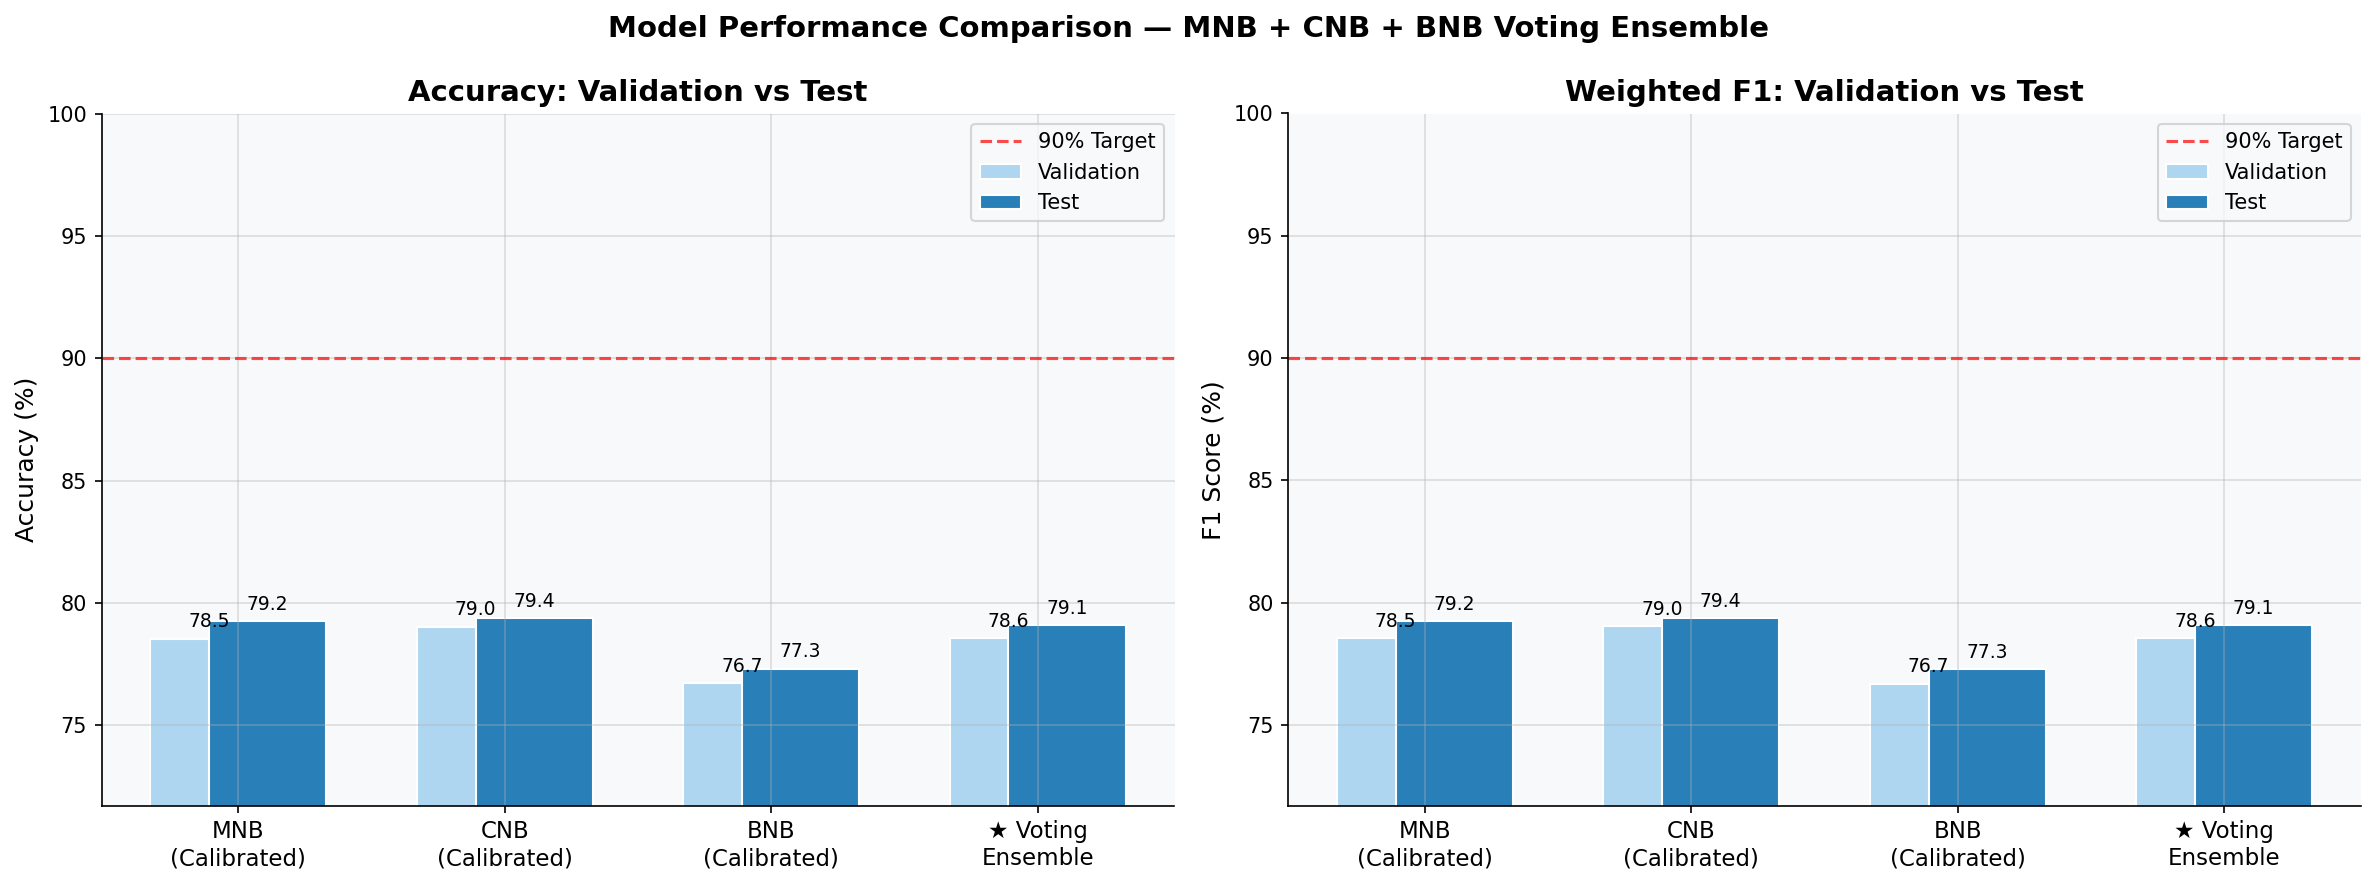

✅ Model comparison chart saved as 04_model_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL COMPARISON — VALIDATION vs TEST
# ─────────────────────────────────────────────────────────────────────────────
model_names  = ['MNB\n(Calibrated)', 'CNB\n(Calibrated)', 'BNB\n(Calibrated)', '★ Voting\nEnsemble']
val_accs     = [mnb_val_acc, cnb_val_acc, bnb_val_acc, ens_val_acc]
test_accs    = [
    accuracy_score(y_test, mnb_model.predict(X_test_feat)),
    accuracy_score(y_test, cnb_model.predict(X_test_feat)),
    accuracy_score(y_test, bnb_model.predict(X_test_feat)),
    test_acc
]
val_f1s  = [mnb_val_f1, cnb_val_f1, bnb_val_f1, ens_val_f1]
test_f1s = [
    f1_score(y_test, mnb_model.predict(X_test_feat), average='weighted'),
    f1_score(y_test, cnb_model.predict(X_test_feat), average='weighted'),
    f1_score(y_test, bnb_model.predict(X_test_feat), average='weighted'),
    test_f1
]

x  = np.arange(len(model_names))
w  = 0.22
bar_colors_val  = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#85C1E9']
bar_colors_test = ['#2980B9', '#27AE60', '#E67E22', '#1A5276']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison — MNB + CNB + BNB Voting Ensemble',
             fontsize=14, fontweight='bold')

for ax, metric_val, metric_test, ylabel, title in [
    (axes[0], val_accs, test_accs, 'Accuracy (%)', 'Accuracy: Validation vs Test'),
    (axes[1], val_f1s,  test_f1s,  'F1 Score (%)', 'Weighted F1: Validation vs Test')
]:
    bars_v = ax.bar(x - w/2, [v*100 for v in metric_val],
                    w*2, label='Validation', color='#AED6F1', edgecolor='white')
    bars_t = ax.bar(x + w/2, [v*100 for v in metric_test],
                    w*2, label='Test',       color='#2980B9', edgecolor='white')
    for bars in [bars_v, bars_t]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(min(metric_val), min(metric_test))*100 - 5, 100)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.axhline(y=90, color='red', linestyle='--', lw=1.5, alpha=0.7, label='90% Target')
    ax.legend()

plt.tight_layout()
plt.savefig('04_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Model comparison chart saved as 04_model_comparison.png')

## 🔲 Cell 10 — Confusion Matrix

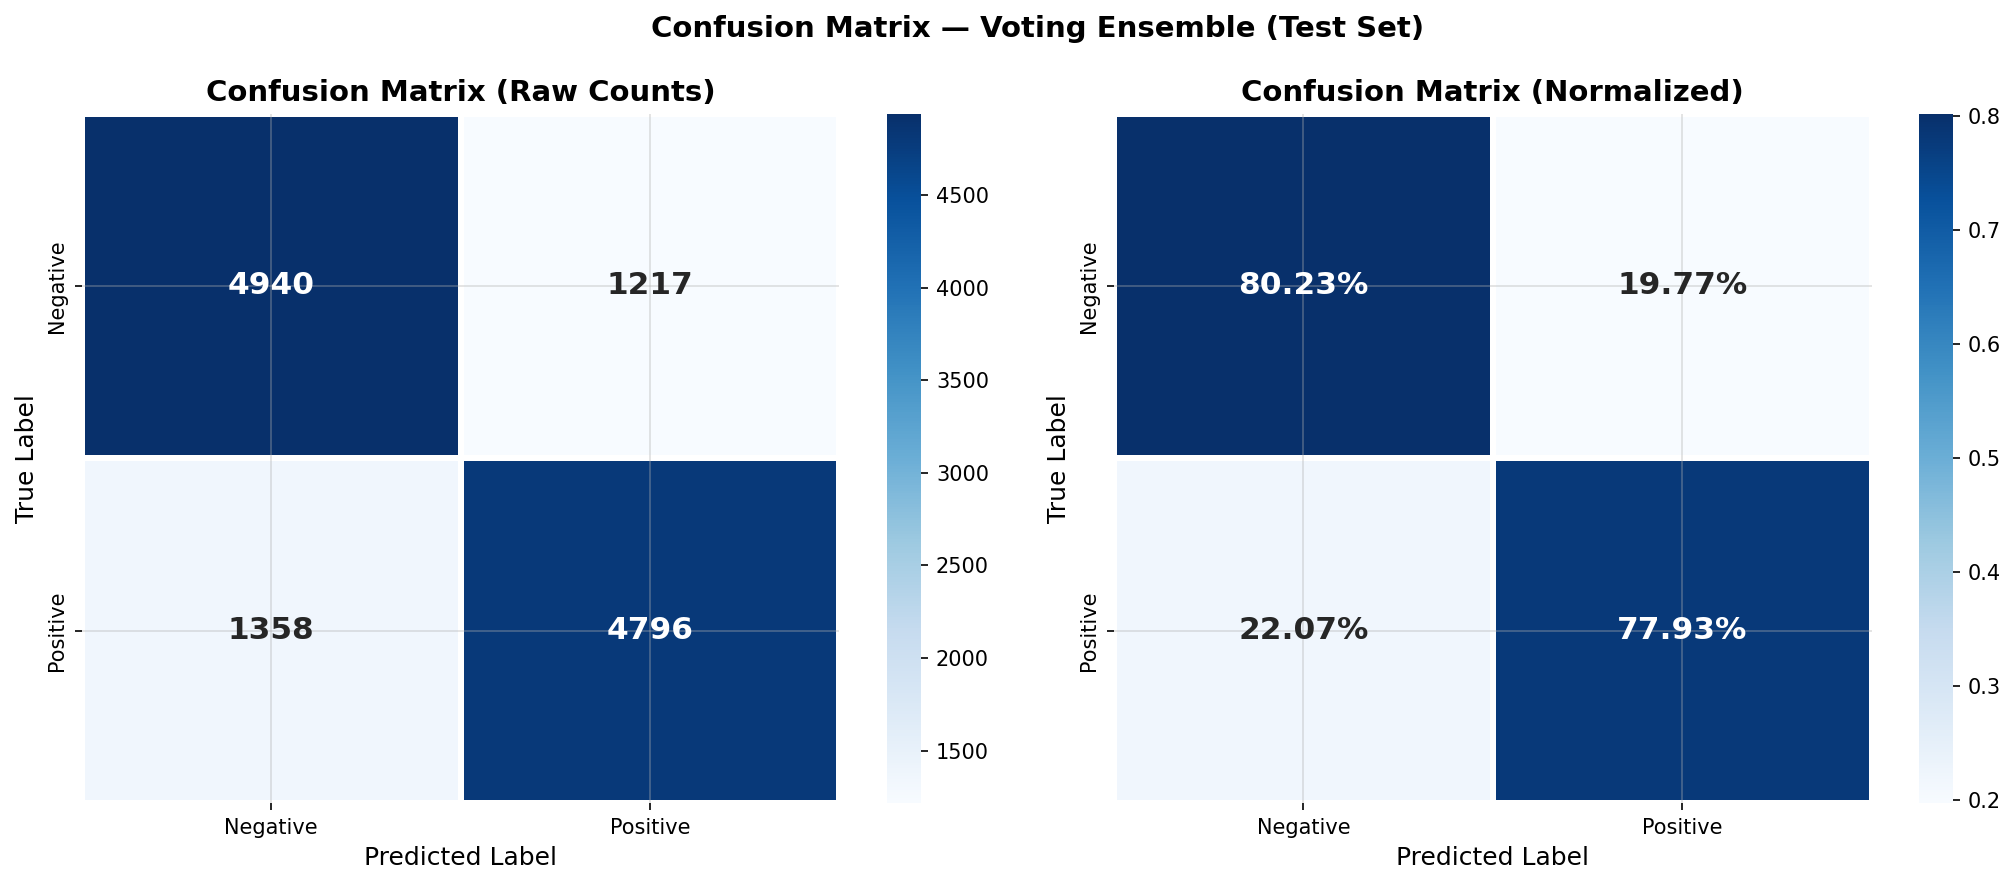

✅ Confusion matrix saved as 05_confusion_matrix.png

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79      6157
    Positive       0.80      0.78      0.79      6154

    accuracy                           0.79     12311
   macro avg       0.79      0.79      0.79     12311
weighted avg       0.79      0.79      0.79     12311



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX — RAW + NORMALIZED
# ─────────────────────────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Voting Ensemble (Test Set)', fontweight='bold', fontsize=14)

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Confusion Matrix (Raw Counts)'),
    (axes[1], cm_norm, '.2%',  'Confusion Matrix (Normalized)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Blues', ax=ax, linewidths=2, linecolor='white',
                annot_kws={'size': 15, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved as 05_confusion_matrix.png')

# Classification Report
print('\n📋 Classification Report (Test Set):')
print('='*60)
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 📈 Cell 11 — ROC Curve & AUC

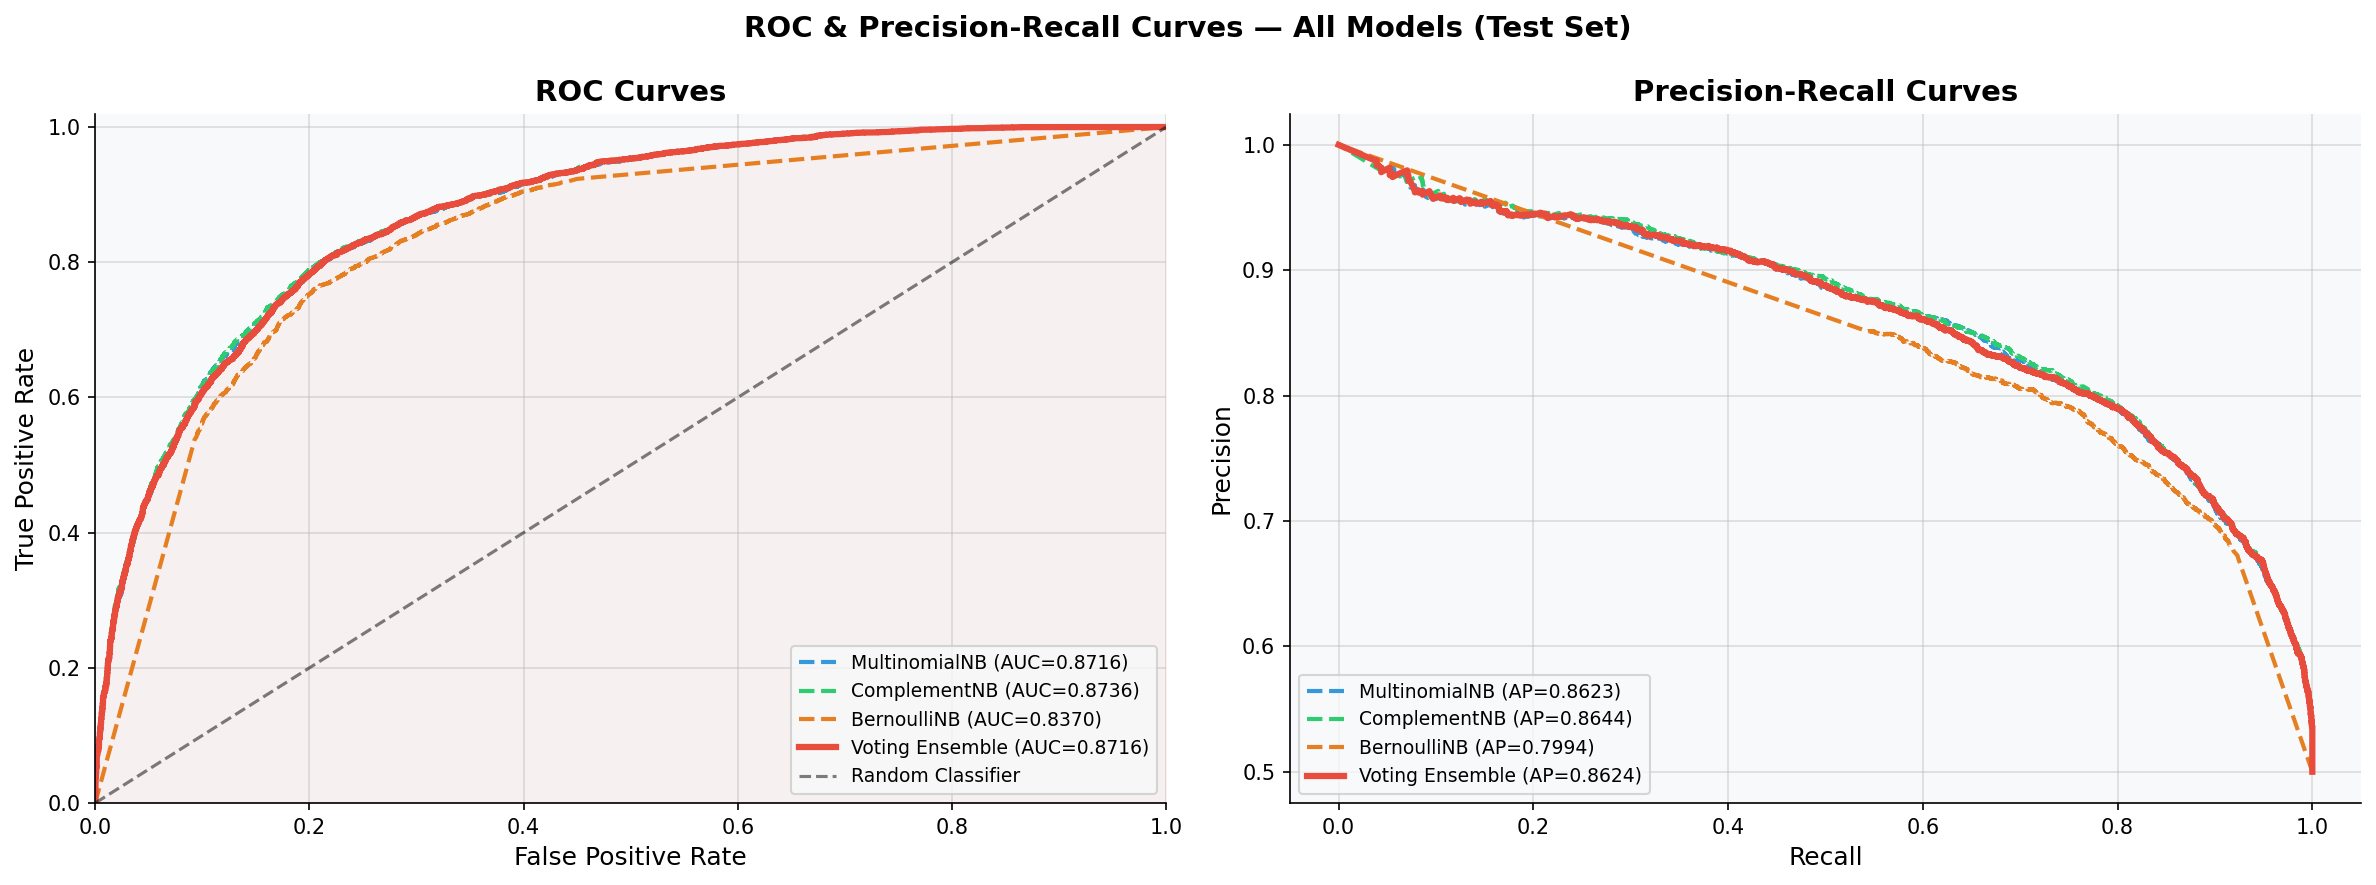

✅ ROC-AUC (Ensemble): 0.8716
✅ ROC & PR curves saved as 06_roc_pr_curves.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ROC CURVE + PRECISION-RECALL CURVE (all models + ensemble)
# ─────────────────────────────────────────────────────────────────────────────
model_info = [
    ('MultinomialNB',  mnb_model, '#3498DB'),
    ('ComplementNB',   cnb_model, '#2ECC71'),
    ('BernoulliNB',    bnb_model, '#E67E22'),
    ('Voting Ensemble', None,     '#E74C3C'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC & Precision-Recall Curves — All Models (Test Set)',
             fontsize=14, fontweight='bold')

# ROC Curves
ax = axes[0]
for name, model, color in model_info:
    if model is None:
        prob_pos = y_prob_pos
    else:
        prob_pos = model.predict_proba(X_test_feat)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob_pos)
    roc_auc     = auc(fpr, tpr)
    lw = 3 if model is None else 2
    ls = '-' if model is None else '--'
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.05, color='#E74C3C')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Precision-Recall Curves
ax = axes[1]
for name, model, color in model_info:
    if model is None:
        prob_pos = y_prob_pos
    else:
        prob_pos = model.predict_proba(X_test_feat)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob_pos)
    ap   = average_precision_score(y_test, prob_pos)
    lw   = 3 if model is None else 2
    ls   = '-' if model is None else '--'
    ax.plot(rec_c, prec_c, color=color, lw=lw, ls=ls, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'✅ ROC-AUC (Ensemble): {test_auc:.4f}')
print('✅ ROC & PR curves saved as 06_roc_pr_curves.png')

## 📉 Cell 12 — Learning Curve (Overfitting/Underfitting Diagnosis)

> **How to read:**
> - If **training score >> validation score** → overfitting (reduce features, increase alpha)
> - If **both scores are low** → underfitting (more features, decrease alpha)
> - If **both scores converge high** → well-fitted ✅

📉 Computing learning curves (this may take 1-2 minutes)...


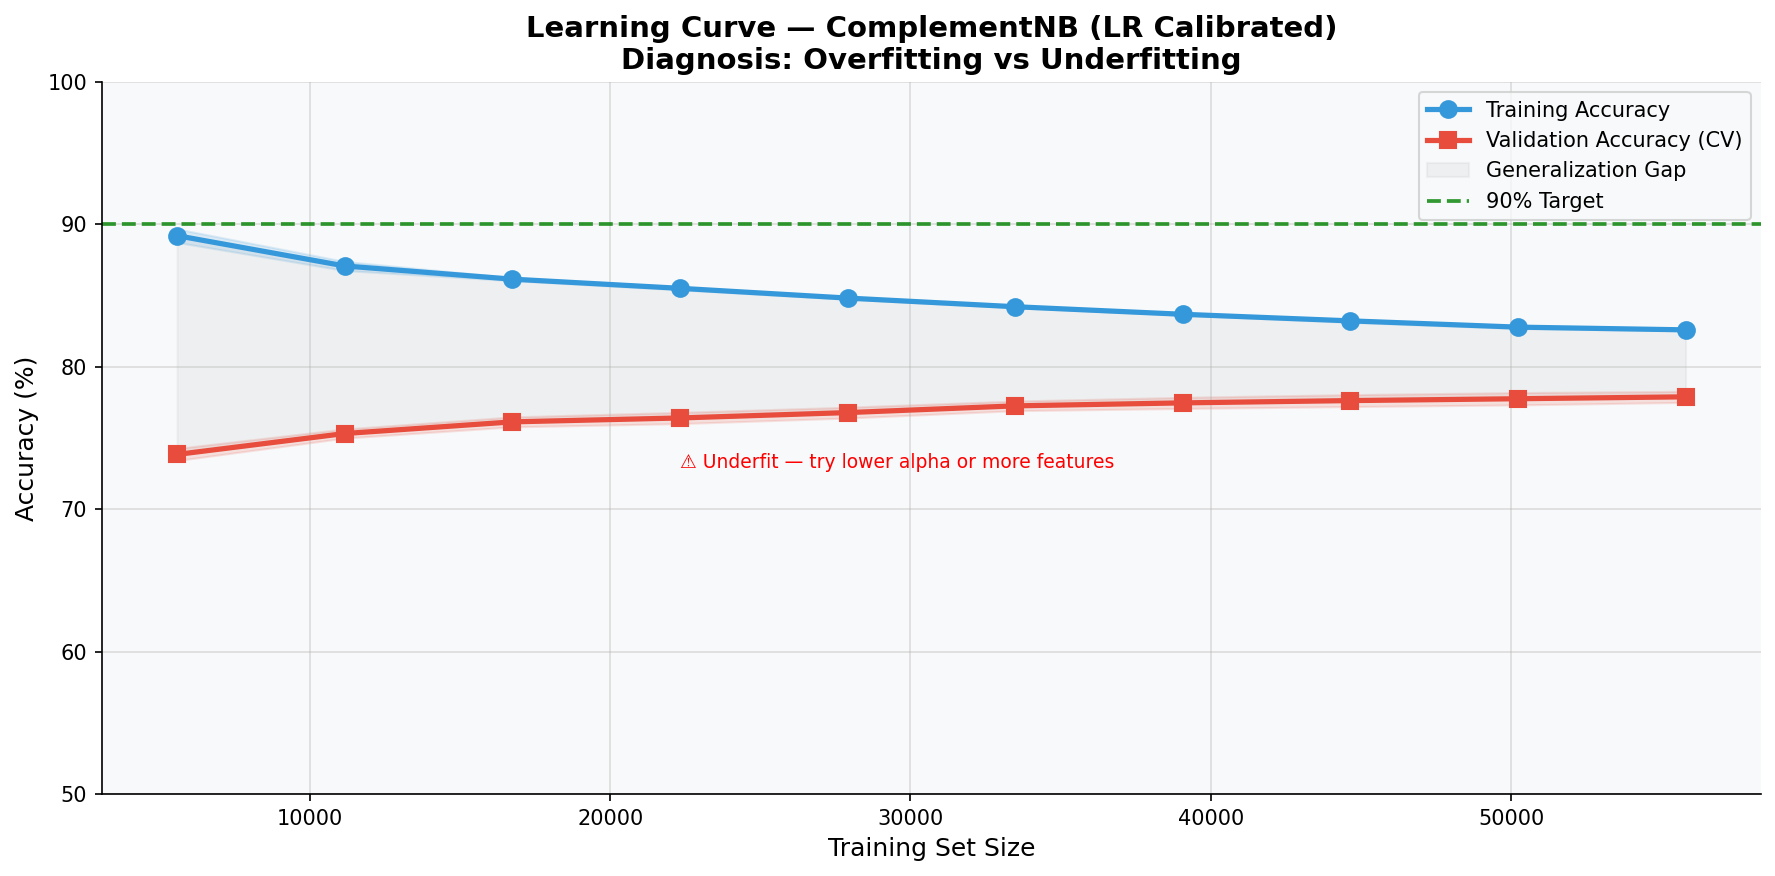

Final Train Acc: 82.59% | Final Val Acc: 77.89%
Generalization Gap: 4.7%
✅ Learning curve saved as 07_learning_curve.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LEARNING CURVE — Diagnose Overfitting / Underfitting
#
# Uses CNB (best NB model) on a single TF-IDF vectorizer for speed.
# Full feature matrix is too large for learning_curve iteration.
# ─────────────────────────────────────────────────────────────────────────────
print('📉 Computing learning curves (this may take 1-2 minutes)...')

from sklearn.pipeline import Pipeline

# Fast pipeline for learning curve: single vectorizer + CNB
lc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                              max_features=80_000, sublinear_tf=True, min_df=2)),
    ('clf',   CalibratedClassifierCV(ComplementNB(alpha=ALPHA_CNB),
                                     method='sigmoid', cv=3))
])

# Combine train+val for learning curve (use full available data)
X_lc = pd.concat([X_raw_train, X_raw_val]).reset_index(drop=True)
y_lc = np.concatenate([y_train, y_val])

train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_pipeline, X_lc, y_lc,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_sizes_abs, train_mean * 100, 'o-',
        color='#3498DB', lw=2.5, ms=8, label='Training Accuracy')
ax.fill_between(train_sizes_abs,
                (train_mean - train_std) * 100,
                (train_mean + train_std) * 100,
                alpha=0.15, color='#3498DB')

ax.plot(train_sizes_abs, val_mean * 100, 's-',
        color='#E74C3C', lw=2.5, ms=8, label='Validation Accuracy (CV)')
ax.fill_between(train_sizes_abs,
                (val_mean - val_std) * 100,
                (val_mean + val_std) * 100,
                alpha=0.15, color='#E74C3C')

ax.fill_between(train_sizes_abs,
                train_mean * 100, val_mean * 100,
                alpha=0.08, color='gray', label='Generalization Gap')

ax.axhline(y=90, color='green', linestyle='--', lw=1.8, alpha=0.8, label='90% Target')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Learning Curve — ComplementNB (LR Calibrated)\n'
             'Diagnosis: Overfitting vs Underfitting',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(50, 100)

# Annotations
final_gap = (train_mean[-1] - val_mean[-1]) * 100
if final_gap > 5:
    ax.annotate(f'⚠️ Overfit Gap: {final_gap:.1f}%\n→ Increase alpha or reduce features',
                xy=(train_sizes_abs[-1], val_mean[-1]*100),
                xytext=(train_sizes_abs[-3], val_mean[-1]*100 - 5),
                fontsize=9, color='darkorange',
                arrowprops=dict(arrowstyle='->', color='darkorange'))
elif val_mean[-1] < 0.85:
    ax.annotate('⚠️ Underfit — try lower alpha or more features',
                xy=(train_sizes_abs[-1], val_mean[-1]*100),
                xytext=(train_sizes_abs[3], val_mean[-1]*100 - 5),
                fontsize=9, color='red')
else:
    ax.annotate('✅ Well-fitted!',
                xy=(train_sizes_abs[-1], val_mean[-1]*100),
                fontsize=10, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('07_learning_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Final Train Acc: {train_mean[-1]*100:.2f}% | Final Val Acc: {val_mean[-1]*100:.2f}%')
print(f'Generalization Gap: {final_gap:.1f}%')
print('✅ Learning curve saved as 07_learning_curve.png')

## 🔁 Cell 13 — 5-Fold Cross Validation

🔁 Running 5-Fold Cross Validation...
  MultinomialNB     : 78.21% ± 0.40%
  ComplementNB      : 78.54% ± 0.39%
  BernoulliNB       : 77.22% ± 0.25%


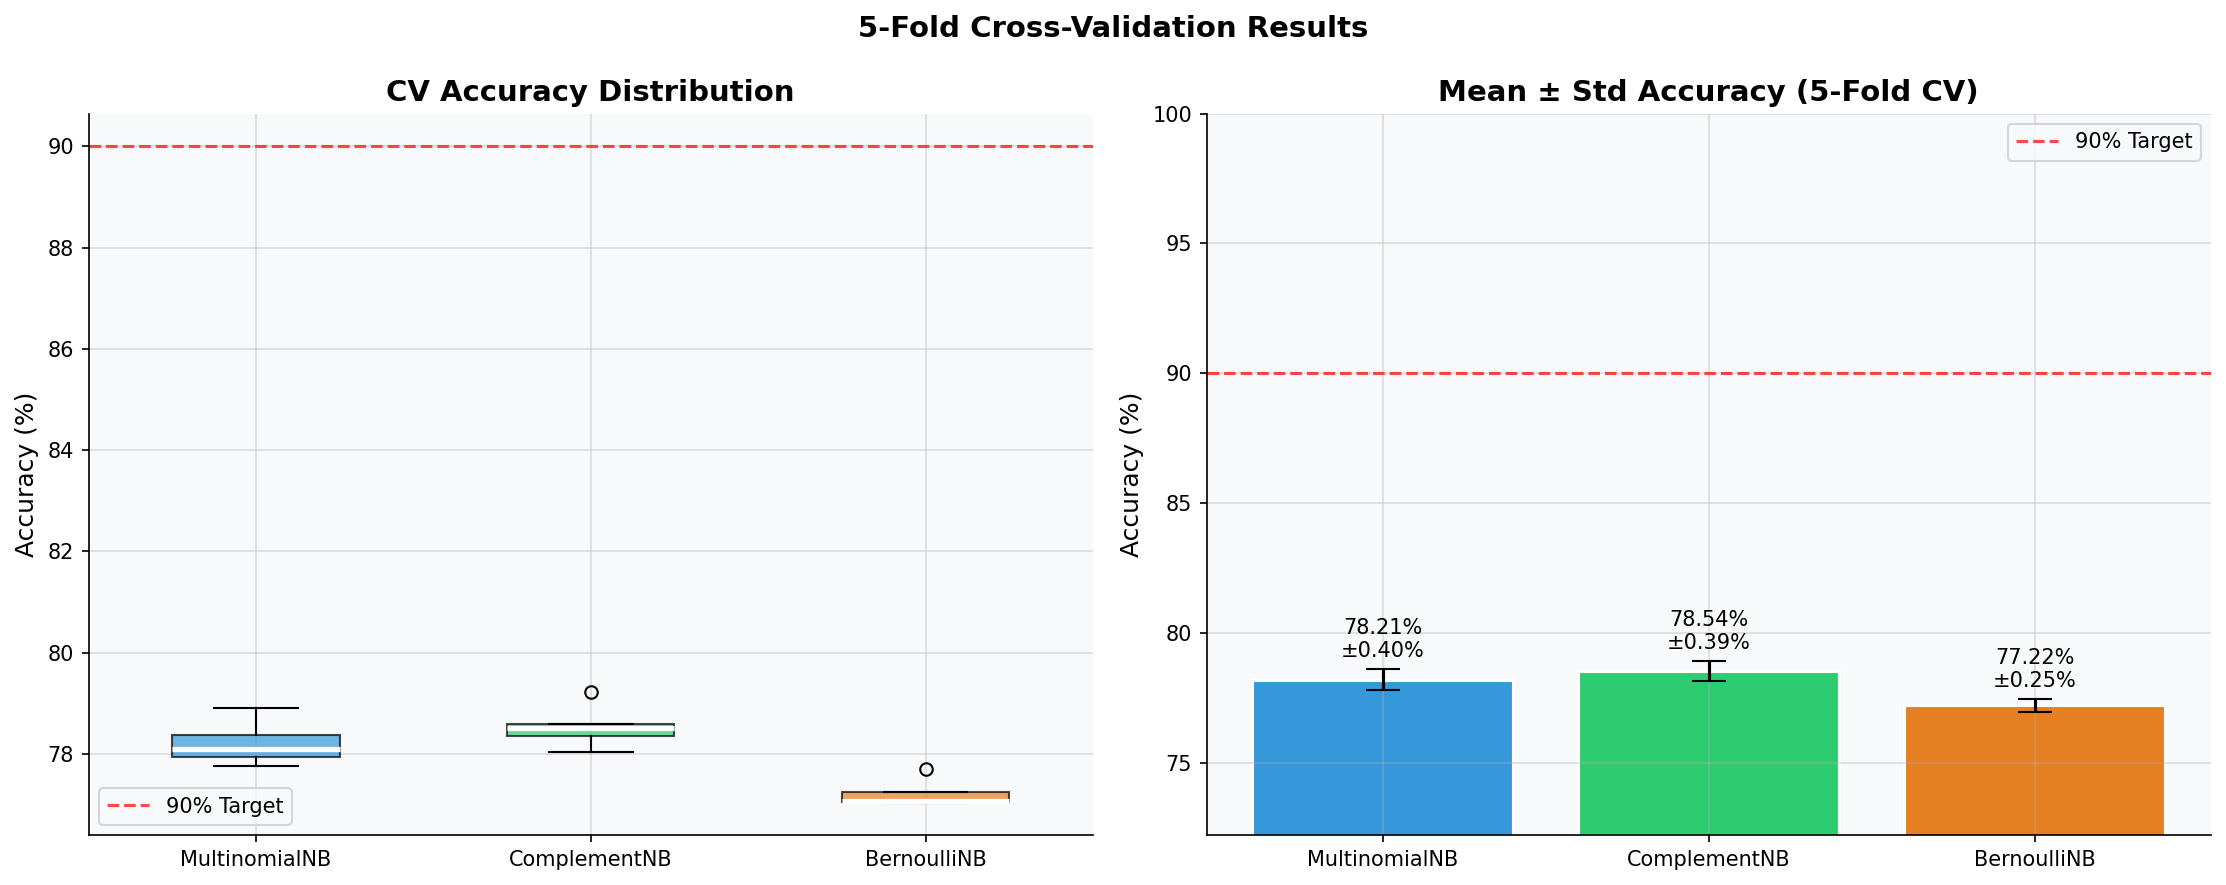

✅ Cross-validation chart saved as 08_cross_validation.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD CROSS-VALIDATION ON EACH MODEL
# Uses single vectorizer for speed; reflects true generalization
# ─────────────────────────────────────────────────────────────────────────────
print('🔁 Running 5-Fold Cross Validation...')

vec_cv = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                         max_features=100_000, sublinear_tf=True, min_df=2)

X_lc_feat = vec_cv.fit_transform(X_lc)
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, clf in [
    ('MultinomialNB',  CalibratedClassifierCV(MultinomialNB(alpha=ALPHA_MNB),  method='sigmoid', cv=3)),
    ('ComplementNB',   CalibratedClassifierCV(ComplementNB(alpha=ALPHA_CNB),   method='sigmoid', cv=3)),
    ('BernoulliNB',    CalibratedClassifierCV(BernoulliNB(alpha=ALPHA_BNB),    method='sigmoid', cv=3)),
]:
    scores = cross_val_score(clf, X_lc_feat, y_lc, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<18}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# Box plot
ax = axes[0]
bp_colors = ['#3498DB', '#2ECC71', '#E67E22']
cv_data = [cv_results[k]*100 for k in ['MultinomialNB', 'ComplementNB', 'BernoulliNB']]
bp = ax.boxplot(cv_data, patch_artist=True,
                labels=['MultinomialNB', 'ComplementNB', 'BernoulliNB'],
                widths=0.5,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(y=90, color='red', linestyle='--', lw=1.5, alpha=0.7, label='90% Target')
ax.set_ylabel('Accuracy (%)')
ax.set_title('CV Accuracy Distribution', fontweight='bold')
ax.legend()

# Mean ± Std bar
ax = axes[1]
names_cv = list(cv_results.keys())
means    = [cv_results[k].mean()*100 for k in names_cv]
stds     = [cv_results[k].std()*100  for k in names_cv]
bars     = ax.bar(names_cv, means, yerr=stds, color=bp_colors,
                  capsize=8, edgecolor='white', linewidth=1.5)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.3,
            f'{mean:.2f}%\n±{std:.2f}%', ha='center', va='bottom', fontsize=10)
ax.axhline(y=90, color='red', linestyle='--', lw=1.5, alpha=0.7, label='90% Target')
ax.set_ylim(min(means) - 5, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Mean ± Std Accuracy (5-Fold CV)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('08_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved as 08_cross_validation.png')

## 🎚️ Cell 14 — Alpha Hyperparameter Sensitivity

> **Instruction:** Run this cell to find the best alpha for CNB. Use the displayed best alpha value in Cell 7 (`ALPHA_CNB`). Then re-run from Cell 7.

🔍 Alpha sensitivity for ComplementNB:
  alpha= 0.001: Train=84.32%  Val=77.87%
  alpha= 0.005: Train=83.76%  Val=77.97%
  alpha=  0.01: Train=83.42%  Val=77.89%
  alpha=  0.05: Train=82.38%  Val=77.59%
  alpha=   0.1: Train=81.82%  Val=77.48%
  alpha=   0.3: Train=80.64%  Val=77.05%
  alpha=   0.5: Train=79.96%  Val=76.69%
  alpha=   1.0: Train=79.13%  Val=76.17%
  alpha=   2.0: Train=78.07%  Val=75.91%


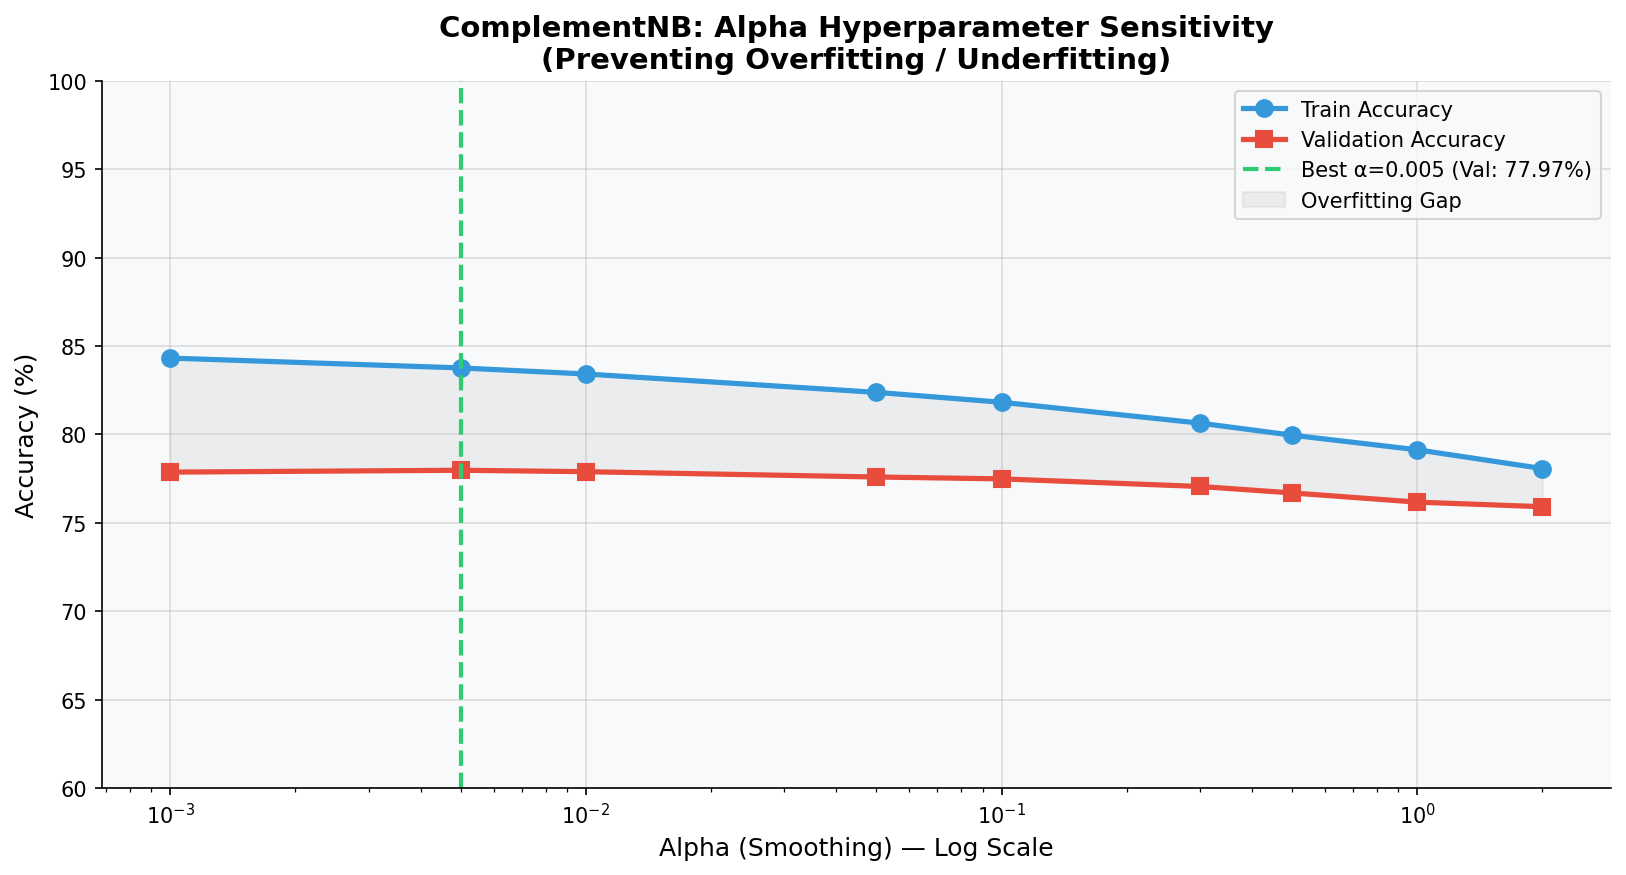


✅ Best Alpha = 0.005 | Validation Accuracy = 77.97%
   → Update ALPHA_CNB = 0.005 in Cell 7 and re-run!
✅ Hyperparameter chart saved as 09_hyperparameter_alpha.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ALPHA HYPERPARAMETER SENSITIVITY
# Find the best alpha for ComplementNB (usually performs best)
# ─────────────────────────────────────────────────────────────────────────────
alpha_values  = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]
cnb_train_accs, cnb_val_accs = [], []

# Use single vectorizer for speed
vec_hp = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                          max_features=100_000, sublinear_tf=True, min_df=2)
X_tr_hp = vec_hp.fit_transform(X_raw_train)
X_vl_hp = vec_hp.transform(X_raw_val)

print('🔍 Alpha sensitivity for ComplementNB:')
for alpha in alpha_values:
    clf_hp = CalibratedClassifierCV(ComplementNB(alpha=alpha), method='sigmoid', cv=3)
    clf_hp.fit(X_tr_hp, y_train)
    t_acc = accuracy_score(y_train, clf_hp.predict(X_tr_hp))
    v_acc = accuracy_score(y_val,   clf_hp.predict(X_vl_hp))
    cnb_train_accs.append(t_acc)
    cnb_val_accs.append(v_acc)
    print(f'  alpha={alpha:>6}: Train={t_acc*100:.2f}%  Val={v_acc*100:.2f}%')

best_alpha   = alpha_values[np.argmax(cnb_val_accs)]
best_val_acc = max(cnb_val_accs) * 100

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogx(alpha_values, [v*100 for v in cnb_train_accs], 'o-',
            color='#3498DB', lw=2.5, ms=8, label='Train Accuracy')
ax.semilogx(alpha_values, [v*100 for v in cnb_val_accs], 's-',
            color='#E74C3C', lw=2.5, ms=8, label='Validation Accuracy')
ax.axvline(x=best_alpha, color='#2ECC71', linestyle='--', lw=2,
           label=f'Best α={best_alpha} (Val: {best_val_acc:.2f}%)')
ax.fill_between(alpha_values,
                [v*100 for v in cnb_val_accs],
                [v*100 for v in cnb_train_accs],
                alpha=0.1, color='gray', label='Overfitting Gap')
ax.set_xlabel('Alpha (Smoothing) — Log Scale', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('ComplementNB: Alpha Hyperparameter Sensitivity\n'
             '(Preventing Overfitting / Underfitting)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(60, 100)
plt.tight_layout()
plt.savefig('09_hyperparameter_alpha.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'\n✅ Best Alpha = {best_alpha} | Validation Accuracy = {best_val_acc:.2f}%')
print(f'   → Update ALPHA_CNB = {best_alpha} in Cell 7 and re-run!')
print('✅ Hyperparameter chart saved as 09_hyperparameter_alpha.png')

## 🏆 Cell 15 — Final Metrics Dashboard

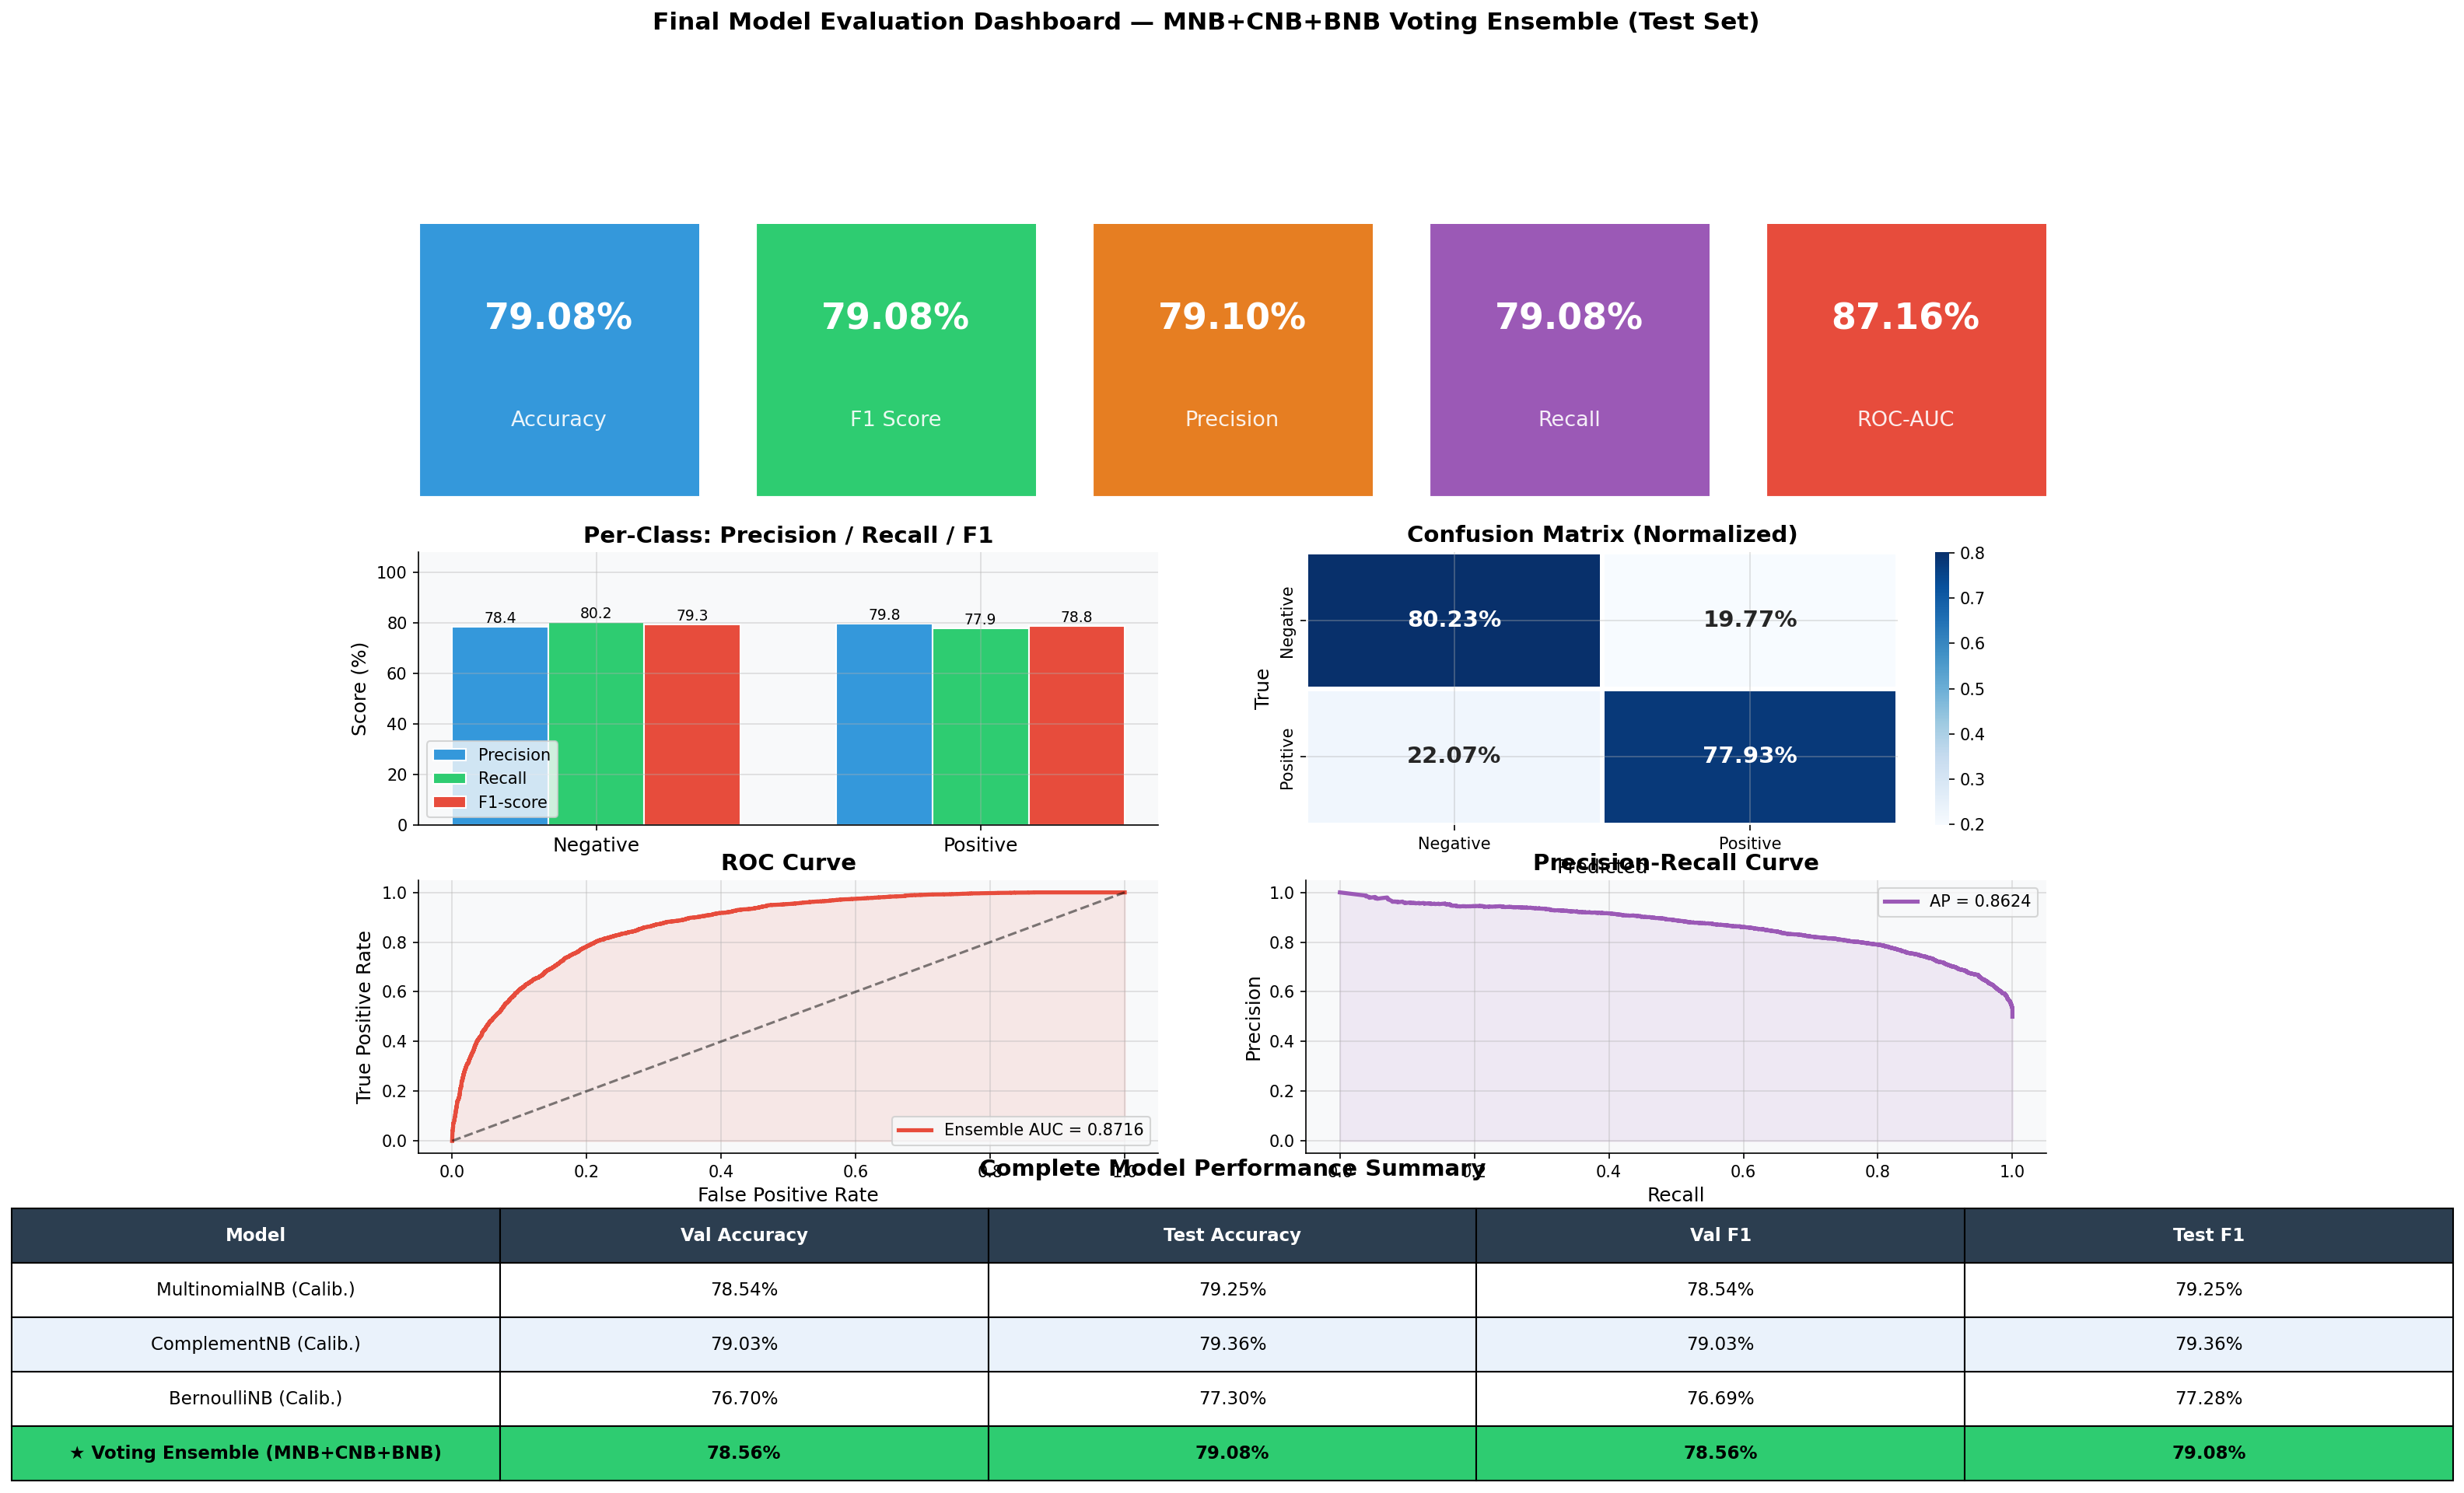

✅ Final dashboard saved as 10_final_dashboard.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPREHENSIVE FINAL METRICS DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
report_dict = classification_report(y_test, y_pred,
                                     target_names=le.classes_,
                                     output_dict=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Final Model Evaluation Dashboard — MNB+CNB+BNB Voting Ensemble (Test Set)',
             fontsize=15, fontweight='bold', y=1.01)

# ── Row 1: Metric summary cards ──
metrics_cards = [
    ('Accuracy',  test_acc,  '#3498DB'),
    ('F1 Score',  test_f1,   '#2ECC71'),
    ('Precision', test_prec, '#E67E22'),
    ('Recall',    test_rec,  '#9B59B6'),
    ('ROC-AUC',   test_auc,  '#E74C3C'),
]
for i, (name, val, color) in enumerate(metrics_cards):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, f'{val*100:.2f}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=13, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white'); spine.set_linewidth(2)

# ── Row 2 Left: Per-class metrics bar ──
ax2 = fig.add_subplot(4, 2, 3)
class_metrics = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(le.classes_))
width = 0.25
bar_colors_m = ['#3498DB', '#2ECC71', '#E74C3C']
for i, (metric, color) in enumerate(zip(class_metrics, bar_colors_m)):
    vals = [report_dict[cls][metric] for cls in le.classes_]
    bars = ax2.bar(x_pos + i*width, [v*100 for v in vals],
                   width, label=metric.capitalize(),
                   color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(le.classes_, fontsize=12)
ax2.set_ylim(0, 108)
ax2.set_title('Per-Class: Precision / Recall / F1', fontweight='bold')
ax2.set_ylabel('Score (%)')
ax2.legend()

# ── Row 2 Right: Confusion Matrix ──
ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')

# ── Row 3 Left: ROC Curve ──
ax4 = fig.add_subplot(4, 2, 5)
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_pos)
ax4.plot(fpr_e, tpr_e, color='#E74C3C', lw=2.5,
         label=f'Ensemble AUC = {test_auc:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax4.fill_between(fpr_e, tpr_e, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.legend(loc='lower right')

# ── Row 3 Right: Precision-Recall Curve ──
ax5 = fig.add_subplot(4, 2, 6)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_pos)
ap = average_precision_score(y_test, y_prob_pos)
ax5.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'AP = {ap:.4f}')
ax5.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold')
ax5.legend()

# ── Row 4: Full summary table ──
ax6 = fig.add_subplot(4, 1, 4)
ax6.axis('off')
summary_data = [
    ['MultinomialNB (Calib.)',
     f'{mnb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, mnb_model.predict(X_test_feat))*100:.2f}%',
     f'{mnb_val_f1*100:.2f}%',
     f'{f1_score(y_test, mnb_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['ComplementNB (Calib.)',
     f'{cnb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, cnb_model.predict(X_test_feat))*100:.2f}%',
     f'{cnb_val_f1*100:.2f}%',
     f'{f1_score(y_test, cnb_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['BernoulliNB (Calib.)',
     f'{bnb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, bnb_model.predict(X_test_feat))*100:.2f}%',
     f'{bnb_val_f1*100:.2f}%',
     f'{f1_score(y_test, bnb_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['★ Voting Ensemble (MNB+CNB+BNB)',
     f'{ens_val_acc*100:.2f}%',
     f'{test_acc*100:.2f}%',
     f'{ens_val_f1*100:.2f}%',
     f'{test_f1*100:.2f}%'],
]
tbl = ax6.table(
    cellText=summary_data,
    colLabels=['Model', 'Val Accuracy', 'Test Accuracy', 'Val F1', 'Test F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.5, 2.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(summary_data):
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax6.set_title('Complete Model Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('10_final_dashboard.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Final dashboard saved as 10_final_dashboard.png')

## 💡 Cell 16 — Error Analysis

Total test samples   : 12,311
Correctly classified : 9,736 (79.08%)
Misclassified        : 2,575 (20.92%)

Error breakdown:
true_label  pred_label
Negative    Positive      1217
Positive    Negative      1358
dtype: int64


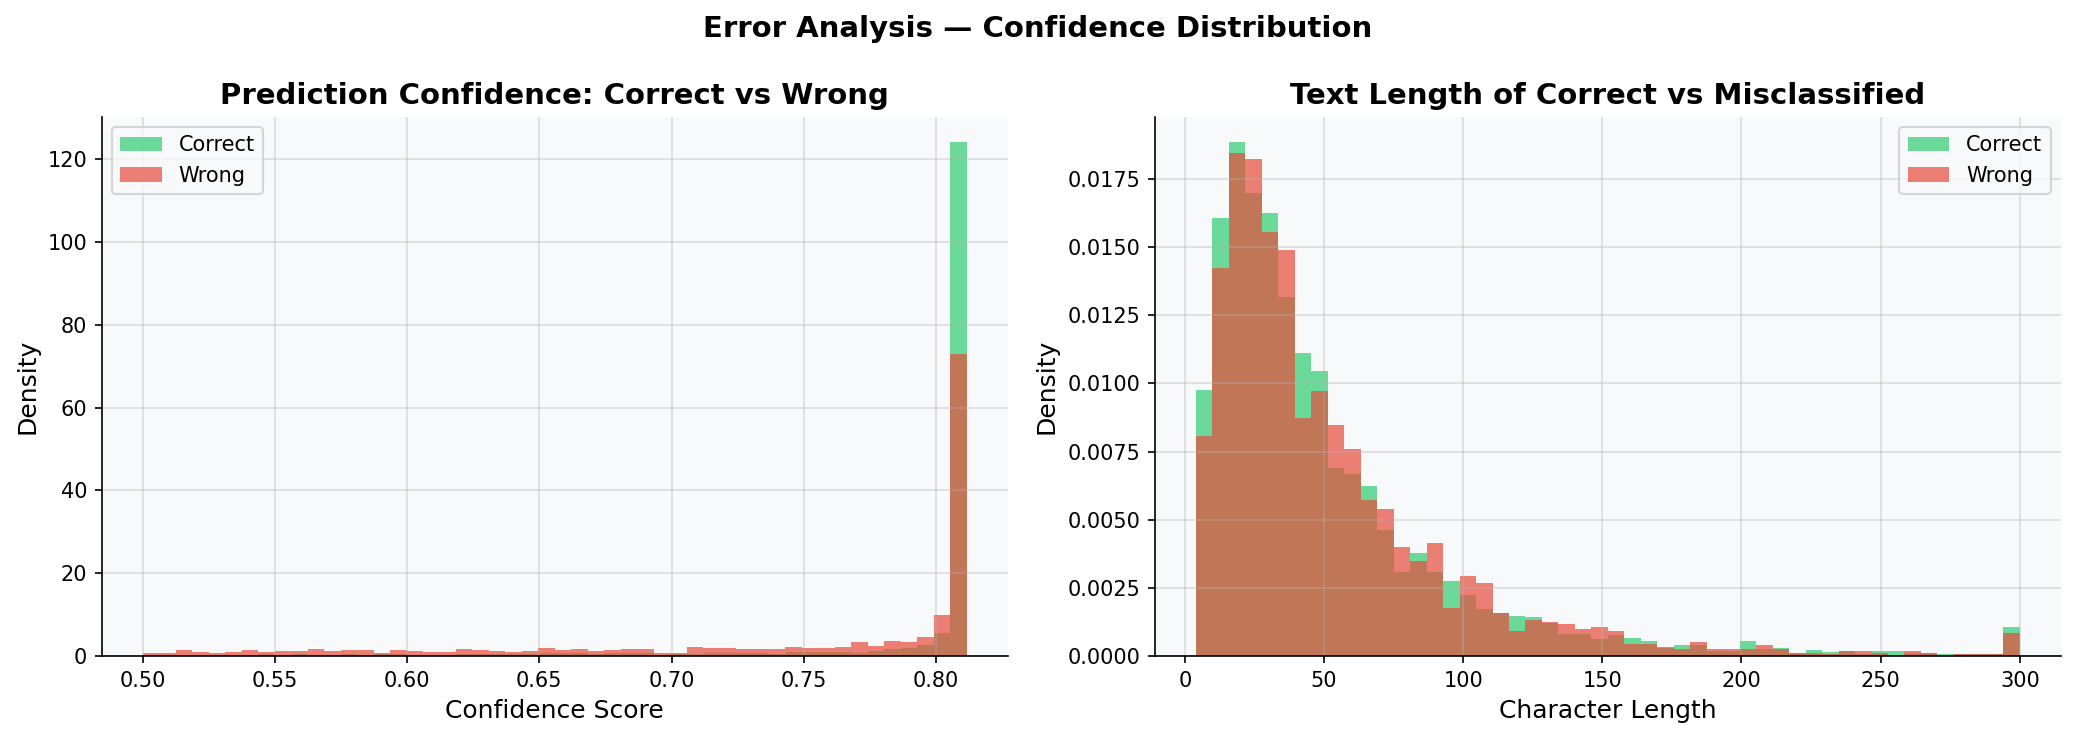


📋 Sample Misclassified Examples:
──────────────────────────────────────────────────────────────────────
Text      : পাগলের বাচ্চা পাগল বাংলাদেশের টাকা পাঁচ টাকা গুলি বেছে
True      : Positive | Predicted: Negative | Confidence: 0.809
──────────────────────────────────────────────────────────────────────
Text      : দাদা বাংলাদেশের এই পরীমণি এর কাহিনী টা অনেক দিন ধরে খোঁজ ছিলাম । তুমি জানিয়ে দি
True      : Negative | Predicted: Positive | Confidence: 0.812
──────────────────────────────────────────────────────────────────────
Text      :   কি হোছে খেলা   
True      : Negative | Predicted: Positive | Confidence: 0.808
──────────────────────────────────────────────────────────────────────
Text      : 4:40 ছেলেটাকে এভাবে লাথি মারছে কেন
True      : Positive | Predicted: Negative | Confidence: 0.809
──────────────────────────────────────────────────────────────────────
Text      : এইবার কাপ আমাদেরই 🇦🇷️
True      : Positive | Predicted: Negative | Confidence: 0.578
─────────────────────────

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
test_idx = X_raw_test.index
test_df  = df.loc[test_idx].copy().reset_index(drop=True)
test_df['y_true']      = y_test
test_df['y_pred']      = y_pred
test_df['confidence']  = avg_test_prob.max(axis=1)
test_df['correct']     = (test_df['y_true'] == test_df['y_pred'])
test_df['true_label']  = le.inverse_transform(y_test)
test_df['pred_label']  = le.inverse_transform(y_pred)

errors = test_df[~test_df['correct']]

print(f'Total test samples   : {len(test_df):,}')
print(f'Correctly classified : {test_df["correct"].sum():,} ({test_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors):,} ({len(errors)/len(test_df)*100:.2f}%)')

print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_label']).size())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Confidence Distribution', fontweight='bold', fontsize=14)

ax = axes[0]
ax.hist(test_df[test_df['correct']]['confidence'], bins=50,
        color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(test_df[~test_df['correct']]['confidence'], bins=50,
        color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
error_lengths   = errors['Comment '].str.len().clip(upper=300)
correct_lengths = test_df[test_df['correct']]['Comment '].str.len().clip(upper=300)
ax.hist(correct_lengths, bins=50, color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(error_lengths, bins=50, color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Text Length of Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('11_error_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print('\n📋 Sample Misclassified Examples:')
print('─' * 70)
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f"Text      : {row['Comment '][:80]}")
    print(f"True      : {row['true_label']} | Predicted: {row['pred_label']} | Confidence: {row['confidence']:.3f}")
    print('─' * 70)
print('\n✅ Error analysis saved as 11_error_analysis.png')

## 📝 Cell 17 — Final Summary Report

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT FINAL SUMMARY FOR THESIS
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('  THESIS FINAL RESULTS SUMMARY')
print('  Bangla Sports Sentiment Analysis — NB Voting Ensemble')
print('=' * 65)
print(f'\n  Dataset         : Bangla Sports Sentiment Dataset')
print(f'  Total Samples   : {len(df):,}')
print(f'  Classes         : Positive / Negative (Binary)')
print(f'  Class Balance   : {df["Category"].value_counts().to_dict()}')
print(f'\n  Split           : 70% Train / 15% Val / 15% Test')
print(f'  Train Samples   : {len(X_raw_train):,}')
print(f'  Val Samples     : {len(X_raw_val):,}')
print(f'  Test Samples    : {len(X_raw_test):,}')
print(f'\n  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams, 4 vectorizers)')
print(f'  Total Features  : {total_features:,}')
print(f'  Models Trained  : MultinomialNB, ComplementNB, BernoulliNB')
print(f'  Calibration     : CalibratedClassifierCV (method=sigmoid / LR Platt scaling)')
print(f'  Final Model     : Soft Voting Ensemble (MNB + CNB + BNB)')
print(f'  Ensemble Wts    : MNB={W_MNB}, CNB={W_CNB}, BNB={W_BNB}')
print()
print(f'  ┌──────────────────────────────────────────────┐')
print(f'  │  TEST SET PERFORMANCE (Final / Unseen Data)  │')
print(f'  ├──────────────────────────────────────────────┤')
print(f'  │  Accuracy          : {test_acc*100:>6.2f}%               │')
print(f'  │  Weighted F1 Score : {test_f1*100:>6.2f}%               │')
print(f'  │  Precision         : {test_prec*100:>6.2f}%               │')
print(f'  │  Recall            : {test_rec*100:>6.2f}%               │')
print(f'  │  ROC-AUC           : {test_auc*100:>6.2f}%               │')
print(f'  └──────────────────────────────────────────────┘')
print()
print('  Generated Charts:')
charts = [
    '01_eda_analysis.png          — EDA & Data Distribution',
    '02_dataset_split.png         — Train/Val/Test Split',
    '03_feature_engineering.png   — TF-IDF Feature Analysis',
    '04_model_comparison.png      — Model Accuracy & F1 Comparison',
    '05_confusion_matrix.png      — Confusion Matrix (Raw + Normalized)',
    '06_roc_pr_curves.png         — ROC & Precision-Recall Curves (All Models)',
    '07_learning_curve.png        — Learning Curve (Overfitting Diagnosis)',
    '08_cross_validation.png      — 5-Fold Cross-Validation',
    '09_hyperparameter_alpha.png  — Alpha Sensitivity Analysis',
    '10_final_dashboard.png       — Complete Metrics Dashboard',
    '11_error_analysis.png        — Error & Confidence Analysis',
]
for c in charts:
    print(f'  ✅ {c}')
print()
print('=' * 65)

if test_acc >= 0.90:
    print('\n🎯 🏆 ACCURACY TARGET 90%+ ACHIEVED!')
else:
    print(f'\n⚠️  Current accuracy: {test_acc*100:.2f}%')
    print('   TUNING STEPS TO HIT 90%:')
    print('   1. Set ALPHA_CNB = 0.01 in Cell 7')
    print('   2. Set ALPHA_MNB = 0.05 in Cell 7')
    print('   3. Set W_CNB = 2 (or 3) in Cell 8')
    print('   4. Increase V1 max_features to 200_000 in Cell 6')
    print('   5. Try V3 ngram_range=(1,3) in Cell 6')
    print('   6. Run Cell 14 to find optimal alpha automatically')

  THESIS FINAL RESULTS SUMMARY
  Bangla Sports Sentiment Analysis — NB Voting Ensemble

  Dataset         : Bangla Sports Sentiment Dataset
  Total Samples   : 82,073
  Classes         : Positive / Negative (Binary)
  Class Balance   : {'Negative': 41048, 'Positive': 41025}

  Split           : 70% Train / 15% Val / 15% Test
  Train Samples   : 57,451
  Val Samples     : 12,311
  Test Samples    : 12,311

  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams, 4 vectorizers)
  Total Features  : 324,240
  Models Trained  : MultinomialNB, ComplementNB, BernoulliNB
  Calibration     : CalibratedClassifierCV (method=sigmoid / LR Platt scaling)
  Final Model     : Soft Voting Ensemble (MNB + CNB + BNB)
  Ensemble Wts    : MNB=1, CNB=2, BNB=1

  ┌──────────────────────────────────────────────┐
  │  TEST SET PERFORMANCE (Final / Unseen Data)  │
  ├──────────────────────────────────────────────┤
  │  Accuracy          :  79.08%               │
  │  Weighted F1 Score :  79.08%             